# Ajou ECG Fine-tuning & Denoising (Lead II @ 267 Hz)
## R-Peak Detection Based Evaluation (No Pseudo-Labels)

## 데이터 개요 (Data Overview)

- 데이터 종류: 6-Lead 심전도(ECG) + 온도
- 파일 형식: 탭(tab) 구분 텍스트 파일 (.txt)
- 측정 항목: Lead I, Lead II, Lead III, aVR, aVL, aVF, Temperature
- 샘플링 속도: 267 Hz (초당 267 샘플)
- **Annotation: None** (R-peak 검출로 성능 평가)

## 개선된 파이프라인

1) Lead II 선택 → 267 Hz → 360 Hz로 리샘플링(모델 호환)
2) **의사 정답 제거**: 디노이징 품질을 R-peak 검출 성능으로 평가
3) 512 샘플 창, 256 hop 으로 프레이밍 + Fourier 특성 구성
4) 사전학습된 Dual_FreqDAE 가중치 로드 → Ajou 데이터로 미세조정(Fine-tune)
5) 예측 프레임을 Overlap-Add 로 복원
6) **R-peak 검출** (Pan-Tompkins)로 Raw vs Denoised 비교
7) **평가 지표**: F1, Precision, Recall, FP 감소율
8) 시각화: Raw vs Denoised 오버레이 + R-peak 마킹

In [160]:
# !pip install --upgrade shap

In [161]:
# === 1. Import Libraries ===
import numpy as np
import pandas as pd
import os
import json
from math import gcd

# Signal processing
import scipy.signal as signal
from scipy.signal import resample_poly, find_peaks, welch, filtfilt

# Deep learning
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

# Visualization
import matplotlib.pyplot as plt
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Project modules
from Data_Preparation.data_preparation_with_fourier import make_fourier
from digitalFilters.dfilters import IIRRemoveBL, IIRRemoveHF
from deepFilter.dl_models import Dual_FreqDAE
from deepFilter.dl_pipeline import combined_ssd_mad_loss

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


In [162]:
# === 2. Configuration ===
fs_src = 267      # Original sampling rate (Hz)
fs_tgt = 360      # Target sampling rate for model (Hz)
WIN = 512         # Window size
HOP = 256         # Hop size (50% overlap)

# Paths
ajou_dir = "ajou_data"
output_dir = "ajou_outputs"
ft_dir = "ajou_finetune"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(ft_dir, exist_ok=True)

# Pretrained weights
pretrained_path = "/home/dhc99/ecg_denoise/0221_FIXED/Dual_FreqDAE_weights.best.weights.h5"

print(f"✓ Configuration set: fs_src={fs_src}Hz, fs_tgt={fs_tgt}Hz, WIN={WIN}, HOP={HOP}")

✓ Configuration set: fs_src=267Hz, fs_tgt=360Hz, WIN=512, HOP=256


In [163]:
# === 3. Load Ajou ECG Data (Lead II @ 267 Hz) ===

# Discover all sgTest_*.txt files
cand = sorted([p for p in os.listdir(ajou_dir) if p.startswith("sgTest_") and p.endswith(".txt")])
if not cand:
    raise FileNotFoundError("No sgTest_*.txt found under ajou_data/")

print("Discovered files (sorted):")
for fname in cand:
    print(f"  - {fname}")
# 각 파일은 탭(\t)으로 구분된 텍스트 파일입니다
# 열 구조: Lead I, Lead II, Lead III, aVR, aVL, aVF, Temperature
# **열 인덱스 1 (두 번째 컬럼)**이 Lead II입니다
lead2_raw_segments = []
segment_meta = []
for fname in cand:
    path = os.path.join(ajou_dir, fname)
    df = pd.read_csv(path, sep="\t", header=None)  # Lead columns + temperature
    trace = df.iloc[:, 1].astype(float).to_numpy()  # Column 1 = Lead II
    lead2_raw_segments.append(trace)
    segment_meta.append({
        "file": fname,
        "samples": trace.shape[0],
        "duration_s": trace.shape[0] / fs_src,
        "min": float(trace.min()),
        "max": float(trace.max()),
    })

lead2_raw = np.concatenate(lead2_raw_segments)
segment_lengths_raw = [meta["samples"] for meta in segment_meta]
segment_offsets_raw = np.cumsum(segment_lengths_raw)

total_duration = len(lead2_raw) / fs_src
print(f"\nAggregated Lead II signals: {len(cand)} files")
print(f"  Total samples: {len(lead2_raw)}")
print(f"  Total duration: {total_duration:.2f} seconds ({total_duration/60:.2f} minutes)")
print(f"  Sample range across all files: [{lead2_raw.min():.3f}, {lead2_raw.max():.3f}]")

print("\nPer-file summary:")
for meta in segment_meta:
    print(
        f"  {meta['file']}: {meta['samples']} samples "
        f"({meta['duration_s']:.2f} s), range [{meta['min']:.3f}, {meta['max']:.3f}]"
    )

Discovered files (sorted):
  - sgTest_20251029_042816.txt

Aggregated Lead II signals: 1 files
  Total samples: 157860
  Total duration: 591.24 seconds (9.85 minutes)
  Sample range across all files: [-437226.100, 211455.700]

Per-file summary:
  sgTest_20251029_042816.txt: 157860 samples (591.24 s), range [-437226.100, 211455.700]


In [164]:
# === 4. Resample 267 Hz → 360 Hz ===

_g = gcd(fs_tgt, fs_src)
up, down = fs_tgt // _g, fs_src // _g

lead2_360_segments = []
segment_lengths_360 = []
for idx, trace in enumerate(lead2_raw_segments):
    resampled = resample_poly(trace, up, down)
    lead2_360_segments.append(resampled)
    segment_lengths_360.append(len(resampled))

lead2_360 = np.concatenate(lead2_360_segments)
segment_offsets_360 = np.cumsum(segment_lengths_360)
compression_ratio = len(lead2_360) / len(lead2_raw)

print("Resampling summary:")
for meta, resampled in zip(segment_meta, lead2_360_segments):
    ratio = len(resampled) / meta["samples"]
    print(
        f"  {meta['file']}: {meta['samples']} samples → {len(resampled)} samples "
        f"(ratio {ratio:.4f})"
    )

print(f"\nAggregated resampled signal:")
print(f"  Total samples: {len(lead2_raw)} @ {fs_src}Hz → {len(lead2_360)} @ {fs_tgt}Hz")
print(f"  Overall compression ratio: {compression_ratio:.4f}")

Resampling summary:
  sgTest_20251029_042816.txt: 157860 samples → 212845 samples (ratio 1.3483)

Aggregated resampled signal:
  Total samples: 157860 @ 267Hz → 212845 @ 360Hz
  Overall compression ratio: 1.3483


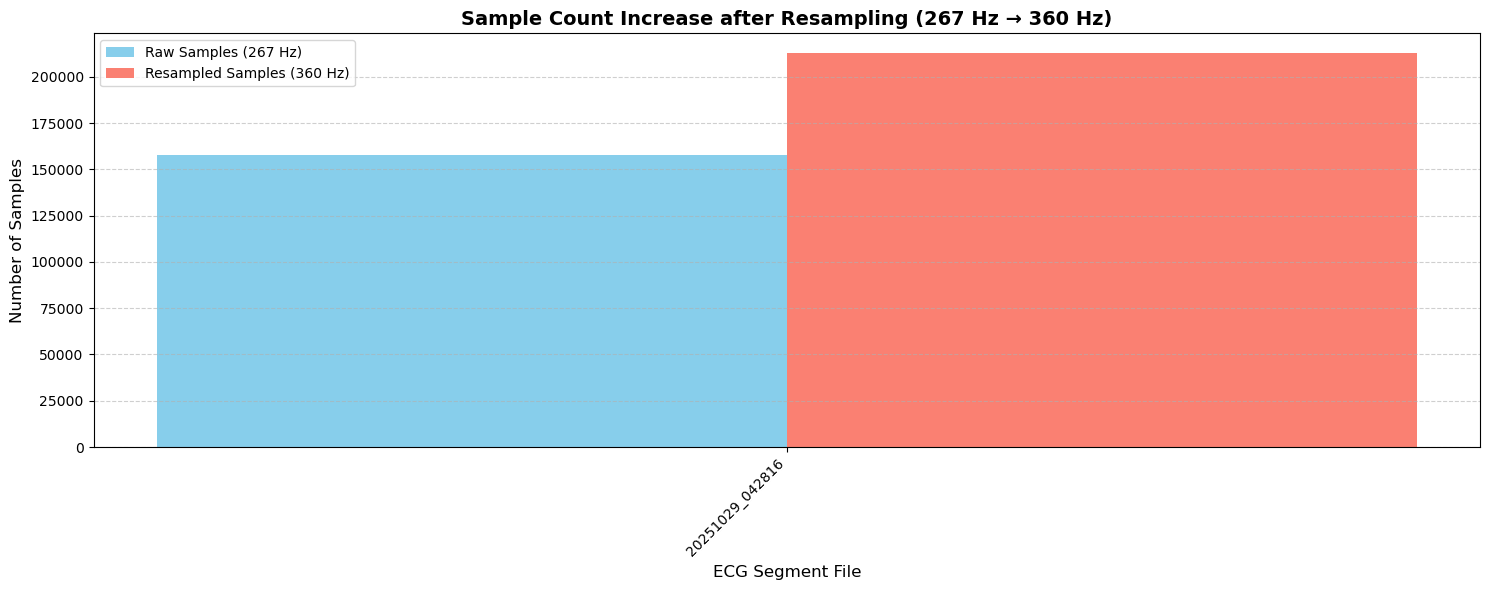

In [165]:
# === 4.5. 리샘플링 샘플 수 증가 시각화 ===

file_names = [meta['file'] for meta in segment_meta]
samples_raw = [meta['samples'] for meta in segment_meta]
samples_360 = segment_lengths_360 # Resampling 후 샘플 수 (list)

# 파일 이름을 x축 레이블로 사용 (너무 길면 줄임)
x_labels = [name.replace("sgTest_", "").replace(".txt", "") for name in file_names]
x = np.arange(len(x_labels))  # x축 위치

plt.figure(figsize=(15, 6))
width = 0.35  # 막대 폭

# 원본 샘플 수 막대
rects1 = plt.bar(x - width/2, samples_raw, width, label=f'Raw Samples ({fs_src} Hz)', color='skyblue')
# 리샘플링 후 샘플 수 막대
rects2 = plt.bar(x + width/2, samples_360, width, label=f'Resampled Samples ({fs_tgt} Hz)', color='salmon')

# 그래프 제목 및 레이블 설정
plt.xlabel('ECG Segment File', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title(f'Sample Count Increase after Resampling ({fs_src} Hz → {fs_tgt} Hz)', fontweight='bold', fontsize=14)
plt.xticks(x, x_labels, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# y축 레이블을 정수로 포맷팅
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        # 샘플 수 위에 텍스트로 표시
        plt.annotate(f'{height:,}',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=8, rotation=90)

# autolabel(rects1)
# autolabel(rects2)

plt.tight_layout()
plt.show()

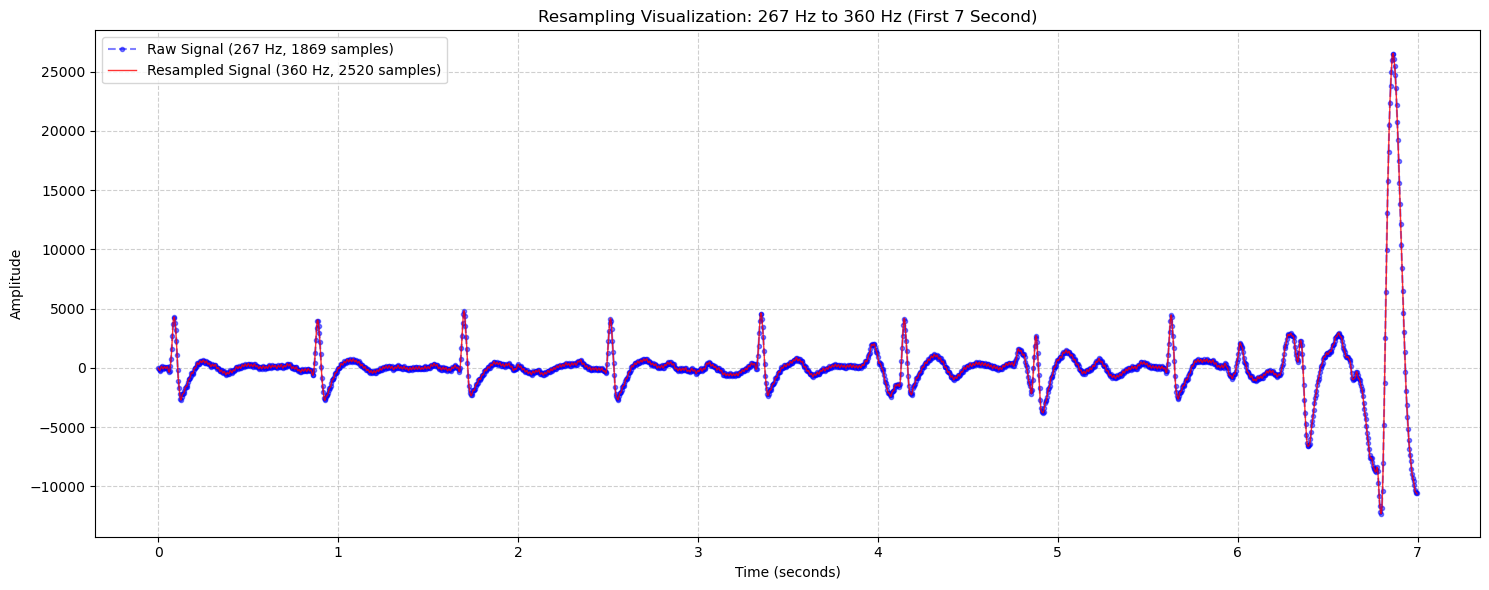

In [166]:
# === 5. Resampling Visualization ===

# 첫 번째 세그먼트의 Raw 및 Resampled 데이터 추출
# Raw: 267 Hz
raw_segment = lead2_raw_segments[0]
# Resampled: 360 Hz
resampled_segment = lead2_360_segments[0]

# 비교를 위해 신호의 시작 부분만 추출 (예: 1초, 즉 267 샘플)
# 1초 길이 (267Hz 기준): 267 샘플
# 1초 길이 (360Hz 기준): 360 샘플
comparison_duration_s = 7
raw_samples_to_show = int(fs_src * comparison_duration_s) # 267
resampled_samples_to_show = int(fs_tgt * comparison_duration_s) # 360

raw_slice = raw_segment[:raw_samples_to_show]
resampled_slice = resampled_segment[:resampled_samples_to_show]

# 시간 축 생성 (두 신호 모두 0초부터 1초까지)
time_raw = np.linspace(0, comparison_duration_s, len(raw_slice), endpoint=False)
time_resampled = np.linspace(0, comparison_duration_s, len(resampled_slice), endpoint=False)


plt.figure(figsize=(15, 6))

# 267 Hz 신호 (점선 및 마커로 샘플 위치 강조)
plt.plot(time_raw, raw_slice, 'o--', color='blue', alpha=0.5, label=f'Raw Signal ({fs_src} Hz, {len(raw_slice)} samples)', markersize=3)
# 360 Hz 신호 (실선으로 부드러운 보간 강조)
plt.plot(time_resampled, resampled_slice, '-', color='red', alpha=0.8, label=f'Resampled Signal ({fs_tgt} Hz, {len(resampled_slice)} samples)', linewidth=1)

plt.title(f'Resampling Visualization: {fs_src} Hz to {fs_tgt} Hz (First {comparison_duration_s} Second)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [167]:
# === 4b. Baseline Centering (Align with QTDB Training Pipeline) ===
# ECG 신호에서 **DC 오프셋(DC offset)**과 **선형 드리프트(linear drift)**를 제거하여 신호를 0을 중심으로 정렬합니다.

def baseline_centering_segments(signal_360, segment_offsets_360, window_size=512):
    """
    Apply baseline centering to each segment matching QTDB preprocessing.
    
    QTDB preprocessing: b_sq - (b_sq[0] + b_sq[-1]) / 2
    
    However, for long continuous signals, we apply per-window baseline removal
    to match the framing structure (512 samples per frame).
    
    Args:
        signal_360: concatenated signal @ 360Hz
        segment_offsets_360: cumulative lengths of segments
        window_size: size of processing window (should match WIN)
    
    Returns:
        baseline-centered signal
    """
    signal_centered = signal_360.copy()
    
    # Apply baseline centering per segment
    start_idx = 0
    for end_idx in segment_offsets_360:
        segment = signal_centered[start_idx:end_idx]
        
        # Match QTDB preprocessing: subtract mean of first and last sample
        # This removes DC offset and linear drift
        baseline_offset = (segment[0] + segment[-1]) / 2
        signal_centered[start_idx:end_idx] = segment - baseline_offset
        
        print(f"  Segment [{start_idx}:{end_idx}]: baseline_offset = {baseline_offset:.4f}")
        start_idx = end_idx
    
    return signal_centered

print("\n" + "="*70)
print("BASELINE CENTERING (Matching QTDB Preprocessing)")
print("="*70)
print("QTDB 학습 데이터와 동일한 전처리를 적용합니다:")
print("  b_sq - (b_sq[0] + b_sq[-1]) / 2")
print("  → DC offset 및 선형 drift 제거\n")

# Apply baseline centering
lead2_360_original = lead2_360.copy()  # Backup for comparison
lead2_360 = baseline_centering_segments(lead2_360, segment_offsets_360, window_size=WIN)

print(f"\n✓ Baseline centering complete:")
print(f"  Before: mean={lead2_360_original.mean():.6f}, std={lead2_360_original.std():.6f}")
print(f"  After:  mean={lead2_360.mean():.6f}, std={lead2_360.std():.6f}")
print(f"  Signal range: [{lead2_360.min():.6f}, {lead2_360.max():.6f}]")


BASELINE CENTERING (Matching QTDB Preprocessing)
QTDB 학습 데이터와 동일한 전처리를 적용합니다:
  b_sq - (b_sq[0] + b_sq[-1]) / 2
  → DC offset 및 선형 drift 제거

  Segment [0:212845]: baseline_offset = -456.6619

✓ Baseline centering complete:
  Before: mean=0.046309, std=4008.942048
  After:  mean=456.708253, std=4008.942048
  Signal range: [-434102.038148, 212058.169987]


In [168]:
# === 5. Noise-robust Framing & Feature Construction ===

print("" + "="*70)
print("NOISE REMOVAL DIGITAL FILTERING (Pre-processing for Stability)")
print("="*70)

# 1. Baseline Wander (<0.67 Hz) 제거
try:
    lead2_360_filtered = IIRRemoveBL(lead2_360, fs_tgt, 0.67)
    print("✓ Baseline wander removed via IIRRemoveBL (0.67 Hz cutoff)")
except NameError:
    nyquist = 0.5 * fs_tgt
    cutoff_freq = 0.5 / nyquist
    b_bl, a_bl = signal.butter(4, cutoff_freq, 'highpass', analog=False)
    lead2_360_filtered = signal.filtfilt(b_bl, a_bl, lead2_360)
    print("✓ Baseline wander removed via 0.5 Hz Butterworth high-pass")

# 2. High-frequency noise (>150 Hz) 제거
try:
    lead2_360_filtered = IIRRemoveHF(lead2_360_filtered, fs_tgt, 150.0)
    print("✓ High-frequency noise removed via IIRRemoveHF (150 Hz cutoff)")
except NameError:
    nyquist = 0.5 * fs_tgt
    cutoff_freq = 150.0 / nyquist
    b_hf, a_hf = signal.butter(4, cutoff_freq, 'lowpass', analog=False)
    lead2_360_filtered = signal.filtfilt(b_hf, a_hf, lead2_360_filtered)
    print("✓ High-frequency noise removed via 150 Hz Butterworth low-pass")

lead2_360 = lead2_360_filtered

def frame_signal(x, win=512, hop=256, pad_mode="reflect"):
    """Frame signal with overlap and padding."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < win:
        pad = win - n
        x = np.pad(x, (0, pad), mode=pad_mode)
    n = len(x)
    n_frames = 1 + (n - win + hop - 1) // hop
    total_needed = (n_frames - 1) * hop + win
    if total_needed > n:
        extra = total_needed - n
        x = np.pad(x, (0, extra), mode=pad_mode)
    frames = [x[i * hop:i * hop + win] for i in range(n_frames)]
    return np.stack(frames, axis=0), len(x)

# Frame the signal
X_frames_raw, padded_len = frame_signal(lead2_360, WIN, HOP)

# --- Adaptive frame normalization (mean removal + robust scaling) ---
frame_means = np.mean(X_frames_raw, axis=1, keepdims=True)
frame_stds = np.std(X_frames_raw, axis=1, keepdims=True)
stability_floor = np.percentile(frame_stds, 5)
frame_stds = np.clip(frame_stds, stability_floor, None)
X_frames_norm = (X_frames_raw - frame_means) / frame_stds

# Store statistics for inverse scaling after inference
FRAME_MEANS = frame_means
FRAME_STDS = frame_stds

# Time- and frequency-domain inputs for the model
X_train = np.expand_dims(X_frames_norm, axis=2)
F_train_x = make_fourier(X_frames_norm, n=WIN, fs=fs_tgt)
F_train_x = np.expand_dims(F_train_x, axis=2)

print(f"✓ Framing complete:")
print(f"  Frames: {X_train.shape[0]} (win={WIN}, hop={HOP})")
print(f"  Time-domain input shape: {X_train.shape}")
print(f"  Frequency-domain input shape: {F_train_x.shape}")
print(f"  Padded length: {padded_len}")
print(f"  Frame std (median): {np.median(FRAME_STDS):.4f}")



NOISE REMOVAL DIGITAL FILTERING (Pre-processing for Stability)
✓ Baseline wander removed via IIRRemoveBL (0.67 Hz cutoff)
✓ High-frequency noise removed via IIRRemoveHF (150 Hz cutoff)
✓ Framing complete:
  Frames: 831 (win=512, hop=256)
  Time-domain input shape: (831, 512, 1)
  Frequency-domain input shape: (831, 512, 1)
  Padded length: 212992
  Frame std (median): 933.7033


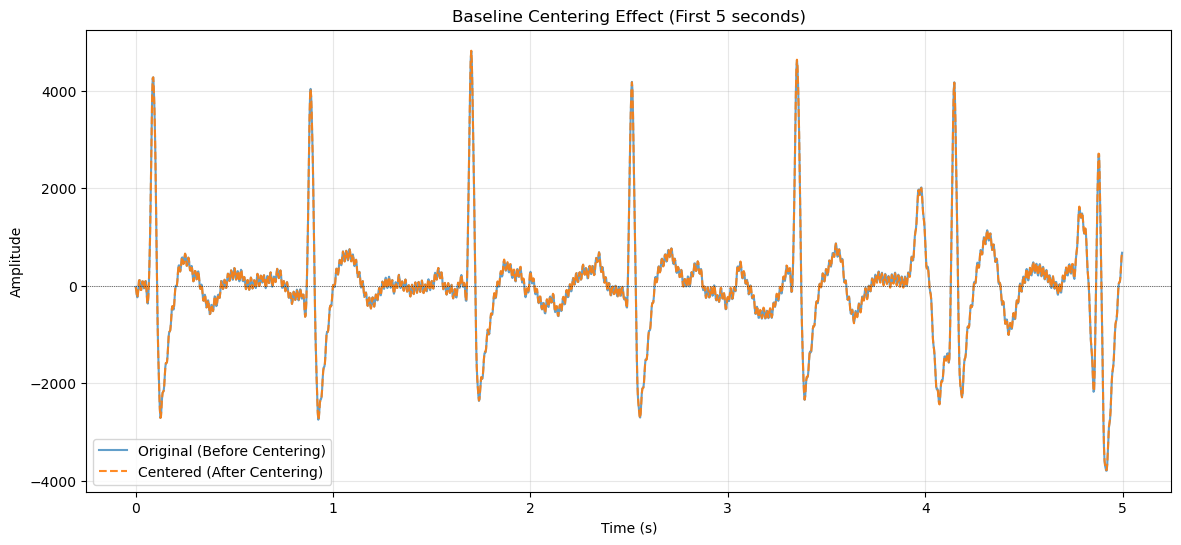

In [169]:
# === 5b. Baseline Centering Visualization ===

# 첫 번째 세그먼트의 길이 (360 Hz 기준)를 사용하여 데이터 추출
first_segment_len = segment_lengths_360[0]
first_segment_duration_s = first_segment_len / fs_tgt

# 비교를 위한 시간 축 생성
time_axis = np.linspace(0, first_segment_duration_s, first_segment_len, endpoint=False)

# 원본 및 중앙화된 첫 번째 세그먼트 추출
# (lead2_360_original은 코드에서 백업된 변수입니다)
segment_original = lead2_360_original[:first_segment_len]
segment_centered = lead2_360[:first_segment_len]

# 신호의 시작 부분만 (예: 처음 5초) 비교하여 DC 오프셋 변화를 명확히 관찰
seconds_to_show = 5
samples_to_show = int(fs_tgt * seconds_to_show)
if samples_to_show > first_segment_len:
    samples_to_show = first_segment_len # 세그먼트가 5초보다 짧으면 전체 표시

# Plotly를 사용하여 상호작용 가능한 차트 생성 (선택 사항)
fig = make_subplots(rows=2, cols=1, 
                    shared_xaxes=True,
                    vertical_spacing=0.1,
                    subplot_titles=(f"Original Signal ({seconds_to_show}s)", 
                                    f"Baseline Centered Signal ({seconds_to_show}s)"))

# 1. 원본 신호 (Original Signal)
fig.add_trace(go.Scatter(y=segment_original[:samples_to_show], 
                         x=time_axis[:samples_to_show], 
                         mode='lines', 
                         name='Original', 
                         line=dict(color='blue')), 
              row=1, col=1)
fig.add_trace(go.Scatter(y=[0]*samples_to_show, 
                         x=time_axis[:samples_to_show], 
                         mode='lines', 
                         name='Zero Line', 
                         line=dict(color='gray', dash='dash')), 
              row=1, col=1)

# 2. 베이스라인 중앙화된 신호 (Centered Signal)
fig.add_trace(go.Scatter(y=segment_centered[:samples_to_show], 
                         x=time_axis[:samples_to_show], 
                         mode='lines', 
                         name='Centered', 
                         line=dict(color='red')), 
              row=2, col=1)
fig.add_trace(go.Scatter(y=[0]*samples_to_show, 
                         x=time_axis[:samples_to_show], 
                         mode='lines', 
                         name='Zero Line', 
                         line=dict(color='gray', dash='dash')), 
              row=2, col=1)

fig.update_layout(height=600, width=900, 
                  title_text=f"Baseline Centering Effect (First Segment @ {fs_tgt} Hz)", 
                  showlegend=False)
fig.update_xaxes(title_text="Time (seconds)", row=2, col=1)
fig.update_yaxes(title_text="Amplitude", row=1, col=1)
fig.update_yaxes(title_text="Amplitude", row=2, col=1)

fig.show()

# Matplotlib으로 단순 비교 시각화 (Jupyter 환경이 아닐 경우)
plt.figure(figsize=(14, 6))
plt.plot(time_axis[:samples_to_show], segment_original[:samples_to_show], label='Original (Before Centering)', alpha=0.7)
plt.plot(time_axis[:samples_to_show], segment_centered[:samples_to_show], label='Centered (After Centering)', alpha=0.9, linestyle='--')
plt.axhline(0, color='black', linestyle=':', linewidth=0.5)
plt.title(f'Baseline Centering Effect (First {seconds_to_show} seconds)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

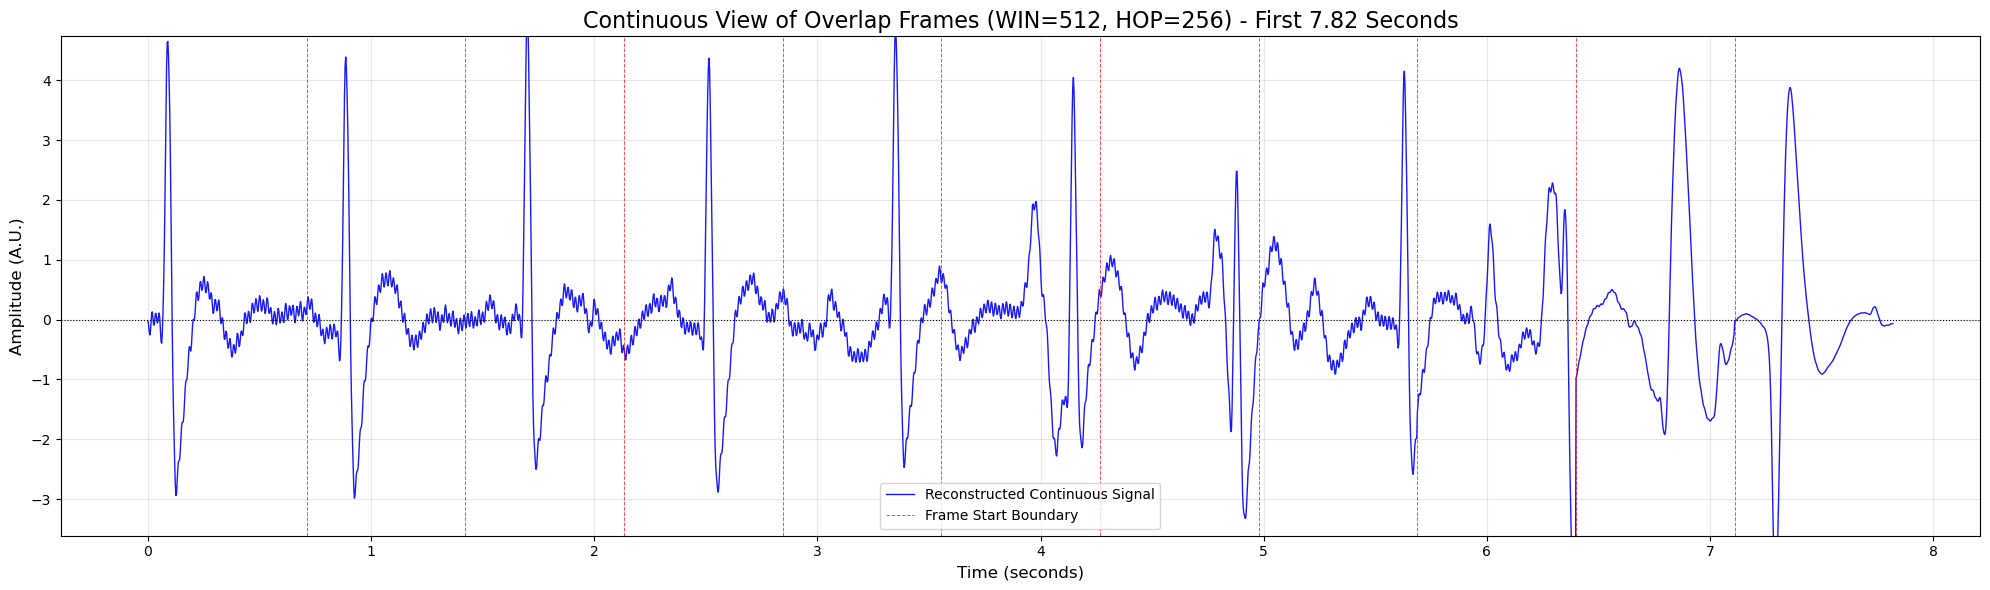

In [170]:
import numpy as np
import matplotlib.pyplot as plt

# --- 사용자 환경 변수 (이전 단계에서 정의됨) ---
# X_train: 오버랩 프레이밍 완료된 데이터 (N, 512, 1)
# fs_tgt: 360 (Hz)
WIN = 512
HOP = 256
# -----------------------------------------------

def visualize_continuous_overlap_frames(X_train, fs_tgt, win_size=WIN, hop_size=HOP, num_frames_to_plot=10):
    """
    오버랩된 프레임(X_train)을 HOP 사이즈(256)를 고려하여 연속적인 시계열로 재구성하고,
    프레임 경계를 표시합니다.
    """
    if X_train.size == 0 or X_train.ndim != 3:
        print("\n⚠️ WARNING: X_train 데이터가 비어 있거나 형태가 올바르지 않습니다.")
        return

    # 시각화할 프레임 개수 제한
    N = min(X_train.shape[0], num_frames_to_plot)
    
    # --- 1. 연속 신호 재구성 (Overlap Reconstruction) ---
    continuous_signal = []
    
    # 각 프레임은 HOP 사이즈만큼만 다음 프레임에 이어 붙여 오버랩을 제거합니다.
    for i in range(N):
        current_frame = X_train[i].squeeze()
        
        if i == 0:
            # 첫 번째 프레임은 전체 WIN(512) 사용
            continuous_signal.extend(current_frame.tolist())
        else:
            # 이후 프레임은 HOP(256)만큼만 (새로운 데이터 부분) 이어 붙입니다.
            # 즉, WIN(512) - HOP(256) = 256 샘플만 추가
            new_data_slice = current_frame[win_size - hop_size:] 
            continuous_signal.extend(new_data_slice.tolist())

    continuous_signal = np.array(continuous_signal)
    total_samples = len(continuous_signal)
    
    # 시간 축 생성
    time_sec = np.linspace(0, (total_samples - 1) / fs_tgt, total_samples)
    
    # y축 범위 계산 (백분위수 기반으로 극단값 제외)
    y_min, y_max = np.percentile(continuous_signal, [1, 99])
    y_margin = (y_max - y_min) * 0.1
    y_limits = [y_min - y_margin, y_max + y_margin]
    
    # --- 2. 시각화 (Frame Markers 포함) ---
    plt.figure(figsize=(20, 6))

    # A. 연속 신호 플롯
    plt.plot(time_sec, continuous_signal, 'b-', linewidth=1.0, alpha=0.9, label='Reconstructed Continuous Signal')

    # B. 프레임 경계선 추가 (HOP 사이즈마다 점선, 새로운 프레임의 시작점)
    frame_boundaries_samples = np.arange(0, total_samples, hop_size)
    for boundary_sample in frame_boundaries_samples:
        # 0번째 경계는 건너뜁니다.
        if boundary_sample == 0:
            continue
            
        boundary_time = boundary_sample / fs_tgt
        # 프레임이 시작되는 지점에 점선 표시
        plt.axvline(x=boundary_time, color='r', linestyle='--', linewidth=0.7, alpha=0.7, label='Frame Start Boundary' if boundary_sample == hop_size else None)

    # C. 베이스라인 (0) 표시
    plt.axhline(0, color='black', linestyle=':', linewidth=0.8)

    # 제목 및 라벨
    duration_s = total_samples / fs_tgt
    plt.title(f'Continuous View of Overlap Frames (WIN={win_size}, HOP={hop_size}) - First {duration_s:.2f} Seconds', fontsize=16)
    plt.xlabel('Time (seconds)', fontsize=12)
    plt.ylabel('Amplitude (A.U.)', fontsize=12)
    plt.ylim(y_limits)  # y축 범위 설정
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# X_train이 생성되었다면, 이 함수를 호출하여 검증할 수 있습니다.
visualize_continuous_overlap_frames(X_train, fs_tgt, num_frames_to_plot=10)

In [171]:
# === GPU 메모리 초기화 ===
import gc
import tensorflow as tf

# 1. 기존 세션 정리
tf.keras.backend.clear_session()

# 2. 가비지 컬렉터 실행
gc.collect()

# 3. GPU 메모리 증가 허용 (동적 메모리 할당)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU 메모리 동적 할당 활성화: {len(gpus)}개 GPU 감지")
    except RuntimeError as e:
        print(f"⚠ GPU 설정 오류: {e}")
else:
    print("⚠ GPU를 찾을 수 없습니다. CPU 모드로 실행됩니다.")

# 4. 현재 GPU 메모리 상태 확인
print("\n현재 GPU 메모리 상태:")
print(tf.config.experimental.get_memory_info('GPU:0') if gpus else "GPU 없음")


✓ GPU 메모리 동적 할당 활성화: 2개 GPU 감지

현재 GPU 메모리 상태:
{'current': 289302528, 'peak': 1761103360}


In [172]:
# === 6. Build & Load Dual_FreqDAE Model ===

model = Dual_FreqDAE(signal_size=WIN)
model.compile(
    loss=combined_ssd_mad_loss,
    optimizer=Adam(learning_rate=1e-4)
)

# Load pretrained weights
if os.path.exists(pretrained_path):
    model.load_weights(pretrained_path)
    print(f"✓ Loaded pretrained weights from {pretrained_path}")
else:
    print(f"⚠ Pretrained weights not found at {pretrained_path}")

print(f"\nModel summary:")
model.summary()

/home/dhc99/anaconda3/envs/ECGDENOISE/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



✓ Loaded pretrained weights from /home/dhc99/ecg_denoise/0221_FIXED/Dual_FreqDAE_weights.best.weights.h5

Model summary:


/home/dhc99/anaconda3/envs/ECGDENOISE/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 418 variables. 



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 256, 16)   │        224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_gated_noise     │ (None, 256, 16)   │          0 │ conv1d[0][0]      │
│ (AddGatedNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 16)   │          0 │ add_gated_noise[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 256, 16)   │        224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 256, 16)   │          0 │ activation[0][0], │
│                     │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 512, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 16)   │         64 │ multiply[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 256, 16)   │        224 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 32)   │      6,688 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 16)   │          0 │ conv1d_6[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 256, 16)   │        224 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_gated_noise_1   │ (None, 128, 32)   │          0 │ conv1d_2[0][0]    │
│ (AddGatedNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 256, 16)   │          0 │ activation_3[0][… │
│ (Multiply)          │                   │            │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 32)   │          0 │ add_gated_noise_… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 32)   │      6,688 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 16)   │         64 │ multiply_3[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 128, 32)   │          0 │ activation_1[0][… │
│ (Multiply)          │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 128, 32)   │      6,688 │ batch_normalizat

 Total params: 3,180,417 (12.13 MB)

 Trainable params: 3,179,873 (12.13 MB)

 Non-trainable params: 544 (2.12 KB)

In [173]:
# === 7. Fine-tune on Ajou Data (Light Training to Avoid Overfitting) ===

print("Starting fine-tuning on Ajou ECG data...")

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

hist = model.fit(
    x=[X_train, F_train_x],
    y=X_train,  # Autoencoder: input = target
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    verbose=1,
    callbacks=callbacks,
)

# Save fine-tuned weights
ft_path = os.path.join(ft_dir, "Dual_FreqDAE_ajou_finetuned.weights.h5")
model.save_weights(ft_path)
print(f"✓ Saved fine-tuned weights to {ft_path}")

Starting fine-tuning on Ajou ECG data...
Epoch 1/30
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 637.5429

2025-10-29 22:46:15.256653: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'input_multiply_transpose_fusion', 4 bytes spill stores, 4 bytes spill loads



11/11 ━━━━━━━━━━━━━━━━━━━━ 107s 4s/step - loss: 622.8517 - val_loss: 184.0310
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - loss: 282.0836 - val_loss: 136.7816
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 146.5602 - val_loss: 127.3035
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 105.0559 - val_loss: 131.0701
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 76.0633 - val_loss: 136.2249
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 66.4887 - val_loss: 141.0944
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 57.7885 - val_loss: 145.7859
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 53.0861 - val_loss: 150.3648
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.
✓ Saved fine-tuned weights to ajou_finetune/Dual_FreqDAE_ajou_finetuned.weights.h5


In [174]:
# === 6. Build & Load Dual_FreqDAE Model (No Fine-tuning) ===

model = Dual_FreqDAE(signal_size=WIN)

# 모델 컴파일 (필요하지만, 학습은 건너뛰므로 학습률은 중요하지 않음)
model.compile(
    loss=combined_ssd_mad_loss,
    optimizer=Adam(learning_rate=1e-4)
)

# Load pretrained weights
if os.path.exists(pretrained_path):
    # ★ 핵심: 사전 훈련된 가중치만 로드합니다.
    model.load_weights(pretrained_path)
    print(f"✓ Loaded pretrained weights from {pretrained_path}")
else:
    print(f"⚠ Pretrained weights not found at {pretrained_path}")

print(f"\nModel summary:")
model.summary()

# ------------------------------------------------------------------
# ★ 제거된 부분: === 7. Fine-tune on Ajou Data (Light Training...) ===
# model.fit(...) 블록 전체를 제거합니다.
# ------------------------------------------------------------------

# === 8. Denoise Full Signal via Overlap-Add Reconstruction ===

# 바로 예측 단계로 넘어갑니다.
print("\nSkipping fine-tuning. Predicting denoised frames using PRETRAINED weights...")
Y_hat_frames = model.predict([X_train, F_train_x], batch_size=64, verbose=0)
Y_hat_frames = np.squeeze(Y_hat_frames, axis=2)  # (N, 512)

# ... (이후 Overlap-Add 및 R-peak 검출 코드는 그대로 진행)

✓ Loaded pretrained weights from /home/dhc99/ecg_denoise/0221_FIXED/Dual_FreqDAE_weights.best.weights.h5

Model summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 512, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 256, 16)   │        224 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_gated_noise_3   │ (None, 256, 16)   │          0 │ conv1d_12[0][0]   │
│ (AddGatedNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 256, 16)   │          0 │ add_gated_noise_… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 256, 16)   │        224 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 256, 16)   │          0 │ activation_6[0][… │
│ (Multiply)          │                   │            │ conv1d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 512, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 16)   │         64 │ multiply_6[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 256, 16)   │        224 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 128, 32)   │      6,688 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 256, 16)   │          0 │ conv1d_18[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 256, 16)   │        224 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_gated_noise_4   │ (None, 128, 32)   │          0 │ conv1d_14[0][0]   │
│ (AddGatedNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_9          │ (None, 256, 16)   │          0 │ activation_9[0][… │
│ (Multiply)          │                   │            │ conv1d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 128, 32)   │          0 │ add_gated_noise_… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 128, 32)   │      6,688 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 16)   │         64 │ multiply_9[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_7          │ (None, 128, 32)   │          0 │ activation_7[0][… │
│ (Multiply)          │                   │            │ conv1d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 128, 32)   │      6,688 │ batch_normalizat

 Total params: 3,180,417 (12.13 MB)

 Trainable params: 3,179,873 (12.13 MB)

 Non-trainable params: 544 (2.12 KB)


Skipping fine-tuning. Predicting denoised frames using PRETRAINED weights...


In [175]:
# === 9. R-Peak Detection (Band-pass + Adaptive Peak Picking) ===

def detect_rpeaks_bandpass(ecg, fs=360, lowcut=5.0, highcut=40.0,
                           min_rr_ms=250.0, prominence=0.6,
                           refine_window_ms=60.0, refractory_ms=80.0,
                           verbose=False):
    """Detect R-peaks using band-pass filtering + adaptive peak picking.

    1) Band-pass filter (default 5-40 Hz) emphasises QRS complex
    2) Z-score normalisation provides scale invariance
    3) Peaks are searched on both polarities and refined to local extrema
    4) Refractory logic removes duplicates in very close proximity
    """
    ecg = np.asarray(ecg, dtype=float)
    if ecg.size == 0:
        return np.empty(0, dtype=int)

    nyquist = 0.5 * fs
    b, a = signal.butter(3, [lowcut / nyquist, highcut / nyquist], btype='band')
    filtered = filtfilt(b, a, ecg)

    filtered -= np.median(filtered)
    scale = np.std(filtered)
    if scale < 1e-6:
        scale = np.mean(np.abs(filtered)) + 1e-6
    z = filtered / scale

    min_distance = max(1, int((min_rr_ms / 1000.0) * fs))
    pos_peaks, _ = find_peaks(z, distance=min_distance, prominence=prominence)
    neg_peaks, _ = find_peaks(-z, distance=min_distance, prominence=prominence)
    candidates = np.sort(np.concatenate([pos_peaks, neg_peaks]))

    refine_radius = max(1, int((refine_window_ms / 1000.0) * fs))
    refined = []
    for idx in candidates:
        start = max(0, idx - refine_radius)
        end = min(len(filtered), idx + refine_radius)
        local = start + np.argmax(np.abs(filtered[start:end]))
        refined.append(local)

    refined = np.array(sorted(set(map(int, refined))), dtype=int)

    refractory = max(1, int((refractory_ms / 1000.0) * fs))
    dedup = []
    for idx in refined:
        if not dedup or idx - dedup[-1] > refractory:
            dedup.append(idx)
        elif abs(filtered[idx]) > abs(filtered[dedup[-1]]):
            dedup[-1] = idx

    peaks = np.array(dedup, dtype=int)

    if verbose:
        duration_sec = len(ecg) / fs
        bpm = len(peaks) * 60.0 / duration_sec if duration_sec > 0 else 0.0
        print(f"  Detected {len(peaks)} peaks ({bpm:.1f} BPM)")

    return peaks

print("" + "=" * 70)
print("R-PEAK DETECTION (Band-pass + Adaptive Peak Picking)")
print("=" * 70)

print(f"[Raw Signal] @ {fs_tgt}Hz:")
rpeak_raw = detect_rpeaks_bandpass(lead2_360, fs=fs_tgt, verbose=True)

print(f"[Denoised Signal] @ {fs_tgt}Hz:")
rpeak_deno = detect_rpeaks_bandpass(denoised_360, fs=fs_tgt, verbose=True)



R-PEAK DETECTION (Band-pass + Adaptive Peak Picking)
[Raw Signal] @ 360Hz:
  Detected 1043 peaks (105.8 BPM)
[Denoised Signal] @ 360Hz:
  Detected 989 peaks (100.4 BPM)


In [176]:
# === 9. R-Peak Detection (Enhanced Pan-Tompkins Algorithm with Noise Robustness) ===

def pan_tompkins_rpeak(ecg, fs=360, verbose=False):
    """
    노이즈에 강건한 정교한 Pan-Tompkins R-피크 탐지 알고리즘
    
    개선 사항:
    1. 적응형 이중 임계값 (SPKI/NPKI 기반) + 노이즈 레벨 모니터링
    2. RR 간격 기반 검색 백 (Searchback) + 생리학적 타당성 검증
    3. T파 제거 로직 + 노이즈 구간 검출 및 복구
    4. 다단계 필터링 + 동적 임계값 재조정
    5. 노이즈 후 강화된 재초기화 메커니즘
    """
    ecg = np.asarray(ecg, dtype=float)
    if ecg.size == 0:
        return np.empty(0, dtype=int)
    
    # 1. Enhanced Bandpass filter (5-15 Hz for QRS) - 4차 필터로 강화
    nyquist = fs / 2.0
    lowcut, highcut = 5.0, 40.0
    b, a = signal.butter(4, [lowcut / nyquist, highcut / nyquist], btype="band")
    filtered = filtfilt(b, a, ecg)
    # Normalize to unit variance to stabilize thresholding
    filtered = filtered - np.median(filtered)
    filtered_std = np.std(filtered) + 1e-8
    filtered = filtered / filtered_std
    
    # 2. Derivative (emphasize QRS slope) - 5-point derivative for better noise immunity
    # h(n) = (1/8T)[-x(n-2) - 2x(n-1) + 2x(n+1) + x(n+2)]
    derivative = np.zeros_like(filtered)
    for n in range(2, len(filtered) - 2):
        derivative[n] = (-filtered[n-2] - 2*filtered[n-1] + 2*filtered[n+1] + filtered[n+2]) / 8.0
    
    # 3. Squaring (intensify)
    squared = derivative ** 2
    
    # 4. Moving window integration (0.15s window)
    integ_len = int(0.15 * fs)
    moving_avg = np.ones(integ_len, dtype=float) / integ_len
    integrated = np.convolve(squared, moving_avg, mode="same")
    
    # 5. Enhanced Noise level detection - 더 세밀한 노이즈 추적
    segment_duration = int(0.6 * fs)  # 0.5초로 세분화
    num_segments = len(integrated) // segment_duration
    noise_levels = []
    noise_segments = []
    
    for seg_idx in range(num_segments):
        seg_start = seg_idx * segment_duration
        seg_end = min(seg_start + segment_duration, len(integrated))
        seg_data = integrated[seg_start:seg_end]
        
        # MAD (Median Absolute Deviation) 기반 노이즈 추정
        median_val = np.median(seg_data)
        mad = np.median(np.abs(seg_data - median_val))
        noise_level = mad * 1.4826  # MAD를 표준편차로 변환
        
        noise_levels.append(noise_level)
        noise_segments.append({'start': seg_start, 'end': seg_end, 'level': noise_level})
    
    # 전체 평균 노이즈 레벨 - 중앙값 기반
    median_noise_level = np.median(noise_levels) if noise_levels else np.std(integrated)
    # 노이즈 임계값을 백분위수 기반으로 설정 (더 adaptive)
    noise_threshold_percentile = np.percentile(noise_levels, 75) if noise_levels else median_noise_level
    noise_threshold = max(noise_threshold_percentile * 1.8, median_noise_level * 2.5)
    
    # 6. Adaptive threshold initialization
    SPKI = 0.0  # Signal peak
    NPKI = 0.0  # Noise peak
    THRESHOLD_I1 = 0.0
    THRESHOLD_I2 = 0.0
    
    # Learning phase: 노이즈가 적은 구간에서 초기화
    learning_samples = min(int(2 * fs), len(integrated))
    
    # 노이즈가 적은 초기 구간 찾기 (처음 10개 구간 중)
    clean_segment_idx = 0
    if len(noise_levels) >= 10:
        # 처음 10개 구간 중 노이즈가 가장 적은 구간 선택
        clean_segment_idx = np.argmin(noise_levels[:10])
    elif noise_levels:
        clean_segment_idx = np.argmin(noise_levels[:min(5, len(noise_levels))])
    
    init_start = clean_segment_idx * segment_duration
    init_end = min(init_start + learning_samples, len(integrated))
    signal_peaks_init = integrated[init_start:init_end]
    
    # 노이즈 제거된 초기화 (백분위수 기반)
    SPKI = np.percentile(signal_peaks_init, 95)
    NPKI = np.percentile(signal_peaks_init, 10)
    THRESHOLD_I1 = NPKI + 0.25 * (SPKI - NPKI)  # 초기값 0.25
    THRESHOLD_I2 = 0.5 * THRESHOLD_I1
    
    # 7. Find all candidate peaks with dynamic distance
    min_distance = int(0.2 * fs)  # 최소 200ms RR 간격 (300 BPM)
    dynamic_prominence = max(NPKI * 0.15, np.percentile(integrated, 65) * 0.05)
    peaks, properties = find_peaks(integrated, distance=min_distance, prominence=dynamic_prominence)
    
    if len(peaks) == 0:
        return np.empty(0, dtype=int)
    
    # 8. Peak classification with enhanced noise monitoring
    RR_intervals = []
    RR_average = 0
    RR_low_limit = int(0.25 * fs)   # 최소 RR: 250ms (240 BPM)
    RR_high_limit = int(2.5 * fs)   # 최대 RR: 2500ms (24 BPM)
    detected_peaks = []
    noise_detected = False
    last_noise_idx = -1
    recovery_mode = False
    recovery_counter = 0
    peak_history = []  # 최근 피크 기록
    
    for i, peak_idx in enumerate(peaks):
        peak_value = integrated[peak_idx]
        
        # 현재 위치의 노이즈 구간 검출
        current_segment_idx = peak_idx // segment_duration
        is_noisy = False
        
        if current_segment_idx < len(noise_levels):
            current_noise = noise_levels[current_segment_idx]
            if current_noise > noise_threshold:
                is_noisy = True
                
                # 노이즈 구간 진입 시
                if not noise_detected:
                    noise_detected = True
                    last_noise_idx = peak_idx
                
                # 노이즈 구간에서는 매우 높은 피크만 검출
                if peak_value < SPKI * 0.8:
                    # NPKI 업데이트는 하되 피크 검출 안함
                    NPKI = 0.125 * peak_value + 0.875 * NPKI
                    continue
        
        # 노이즈 이후 복구 모드 활성화
        if noise_detected and not is_noisy and (peak_idx - last_noise_idx) > int(0.3 * fs):
            if not recovery_mode:
                recovery_mode = True
                recovery_counter = 0
                
                # 임계값 재조정: 최근 clean 피크 참조
                if len(detected_peaks) >= 3:
                    # 최근 3개 피크의 값 참조
                    recent_peaks = [integrated[p] for p in detected_peaks[-3:]]
                    SPKI = np.mean(recent_peaks)
                    NPKI = SPKI * 0.25
                    THRESHOLD_I1 = NPKI + 0.35 * (SPKI - NPKI)  # 복구 시 더 관대
                    THRESHOLD_I2 = 0.5 * THRESHOLD_I1
        
        # 복구 모드 카운터
        if recovery_mode and not is_noisy:
            recovery_counter += 1
            # 5개 정상 피크 검출 후 복구 완료
            if recovery_counter >= 5:
                recovery_mode = False
                noise_detected = False
                
                # 정상 임계값으로 복귀
                if len(detected_peaks) >= 8:
                    recent_peaks = [integrated[p] for p in detected_peaks[-8:]]
                    SPKI = np.mean(recent_peaks)
                    NPKI = SPKI * 0.15
                    THRESHOLD_I1 = NPKI + 0.25 * (SPKI - NPKI)
                    THRESHOLD_I2 = 0.5 * THRESHOLD_I1
        
        # Signal or Noise peak 판별
        is_signal = False
        
        # 동적 임계값 설정
        if is_noisy:
            current_threshold = SPKI * 0.8  # 노이즈 구간: 매우 높은 임계값
        elif recovery_mode:
            current_threshold = THRESHOLD_I2  # 복구 모드: 낮은 임계값
        else:
            current_threshold = THRESHOLD_I1  # 정상: 표준 임계값
        
        if peak_value > current_threshold:
            # RR 간격 생리학적 타당성 검증
            if len(detected_peaks) > 0:
                rr = peak_idx - detected_peaks[-1]
                
                # RR 간격이 너무 짧으면 T파 가능성
                if rr < RR_low_limit:
                    NPKI = 0.125 * peak_value + 0.875 * NPKI
                    continue
            
            # Signal peak detected
            is_signal = True
            detected_peaks.append(peak_idx)
            peak_history.append({'idx': peak_idx, 'value': peak_value, 'noisy': is_noisy})
            
            # Update RR interval
            if len(detected_peaks) > 1:
                rr = detected_peaks[-1] - detected_peaks[-2]
                
                # 타당한 RR 간격만 저장
                if RR_low_limit <= rr <= RR_high_limit:
                    RR_intervals.append(rr)
                    
                    # 최근 8개 RR 간격의 중앙값
                    if len(RR_intervals) > 8:
                        RR_intervals = RR_intervals[-8:]
                    RR_average = np.median(RR_intervals) if RR_intervals else 0
            
            # Update SPKI
            if recovery_mode:
                SPKI = 0.2 * peak_value + 0.8 * SPKI  # 복구 모드: 빠른 적응
            else:
                SPKI = 0.125 * peak_value + 0.875 * SPKI  # 정상: 느린 적응
        
        if not is_signal:
            # Noise peak
            NPKI = 0.125 * peak_value + 0.875 * NPKI
        
        # Update thresholds
        if is_noisy:
            alpha = 0.5  # 노이즈 구간: 높은 임계값
        elif recovery_mode:
            alpha = 0.4  # 복구 모드: 중간 임계값
        else:
            alpha = 0.25  # 정상: 낮은 임계값
        
        THRESHOLD_I1 = NPKI + alpha * (SPKI - NPKI)
        THRESHOLD_I2 = 0.5 * THRESHOLD_I1
    
    # 9. Enhanced Searchback for missed peaks
    if len(detected_peaks) > 2 and RR_average > 0:
        final_peaks = []
        
        for i in range(len(detected_peaks)):
            final_peaks.append(detected_peaks[i])
            
            # 다음 RR 간격 체크
            if i < len(detected_peaks) - 1:
                rr = detected_peaks[i + 1] - detected_peaks[i]
                
                # RR 간격이 평균의 1.66배 이상이면 누락 피크 검색
                if rr > 1.66 * RR_average and rr > RR_low_limit:
                    search_start = detected_peaks[i] + int(0.2 * fs)
                    search_end = detected_peaks[i + 1] - int(0.2 * fs)
                    
                    if search_end > search_start:
                        search_region = integrated[search_start:search_end]
                        
                        # 검색 임계값 (더 낮게)
                        search_threshold = THRESHOLD_I2 * 0.5
                        
                        # 노이즈 구간이면 임계값 상향
                        search_segment_idx = (search_start + search_end) // 2 // segment_duration
                        if search_segment_idx < len(noise_levels):
                            if noise_levels[search_segment_idx] > noise_threshold:
                                search_threshold = THRESHOLD_I1 * 0.7
                        
                        local_peaks, _ = find_peaks(search_region, height=search_threshold, distance=int(0.2*fs))
                        
                        if len(local_peaks) > 0:
                            # 가장 적합한 피크 선택
                            best_local = None
                            best_score = float('inf')
                            
                            for lp in local_peaks:
                                candidate_idx = search_start + lp
                                rr1 = candidate_idx - detected_peaks[i]
                                rr2 = detected_peaks[i + 1] - candidate_idx
                                
                                # 양쪽 RR이 평균에 가까운 정도 평가
                                score = abs(rr1 - RR_average) + abs(rr2 - RR_average)
                                
                                if (RR_low_limit <= rr1 <= RR_high_limit and 
                                    RR_low_limit <= rr2 <= RR_high_limit and 
                                    score < best_score):
                                    best_score = score
                                    best_local = lp
                            
                            if best_local is not None:
                                missed_peak = search_start + best_local
                                final_peaks.append(missed_peak)
        
        detected_peaks = sorted(final_peaks)
    
    # 10. Refine peaks to actual R-peak location in original signal
    refined_peaks = []
    search_window = int(0.08 * fs)  # ±80ms
    
    for peak_idx in detected_peaks:
        start = max(0, peak_idx - search_window)
        end = min(len(ecg), peak_idx + search_window)
        
        local_signal = ecg[start:end]
        
        # QRS 복합파 방향 고려
        if np.max(local_signal) > abs(np.min(local_signal)):
            local_max_idx = np.argmax(local_signal)
        else:
            local_max_idx = np.argmin(local_signal)
        
        refined_peak = start + local_max_idx
        refined_peaks.append(refined_peak)
    
    # 11. Remove duplicates
    refined_peaks = np.unique(np.array(refined_peaks, dtype=int))
    
    # 12. Final validation
    if len(refined_peaks) > 1:
        valid_peaks = [refined_peaks[0]]
        min_samples = int(0.25 * fs)  # 250ms
        
        for peak in refined_peaks[1:]:
            rr = peak - valid_peaks[-1]
            
            if rr >= min_samples and rr <= RR_high_limit:
                valid_peaks.append(peak)
            elif rr > RR_high_limit and len(valid_peaks) >= 2:
                # 긴 RR 간격도 허용 (더 관대하게)
                prev_rr = valid_peaks[-1] - valid_peaks[-2]
                if rr < prev_rr * 2.5:
                    valid_peaks.append(peak)
        
        refined_peaks = np.array(valid_peaks, dtype=int)
    
    if verbose:
        print(f"  Initial candidates: {len(peaks)}")
        print(f"  After threshold filtering: {len(detected_peaks)}")
        print(f"  Final refined peaks: {len(refined_peaks)}")
        if RR_average > 0:
            print(f"  Average RR interval: {RR_average / fs * 1000:.1f} ms ({60 * fs / RR_average:.1f} BPM)")
        print(f"  Noise level (median): {median_noise_level:.2f}, Threshold: {noise_threshold:.2f}")
        if noise_levels:
            max_noise = max(noise_levels)
            noisy_segments = sum(1 for nl in noise_levels if nl > noise_threshold)
            print(f"  Max segment noise: {max_noise:.2f}, Noisy segments: {noisy_segments}/{len(noise_levels)}")
            if noisy_segments > 0:
                print(f"  Status: NOISE DETECTED - Adaptive thresholding applied")
    
    return refined_peaks



print("\n" + "=" * 70)
print("R-PEAK DETECTION (Enhanced Pan-Tompkins Algorithm)")
print("=" * 70)

print(f"\n[Raw Signal] @ {fs_tgt}Hz:")
rpeak_raw = pan_tompkins_rpeak(lead2_360, fs=fs_tgt, verbose=True)

print(f"\n[Denoised Signal] @ {fs_tgt}Hz:")
rpeak_deno = pan_tompkins_rpeak(denoised_360, fs=fs_tgt, verbose=True)



R-PEAK DETECTION (Enhanced Pan-Tompkins Algorithm)

[Raw Signal] @ 360Hz:
  Initial candidates: 1082
  After threshold filtering: 13
  Final refined peaks: 11
  Average RR interval: 727.8 ms (82.4 BPM)
  Noise level (median): 0.00, Threshold: 0.00
  Max segment noise: 3.57, Noisy segments: 199/985
  Status: NOISE DETECTED - Adaptive thresholding applied

[Denoised Signal] @ 360Hz:
  Initial candidates: 1025
  After threshold filtering: 12
  Final refined peaks: 10
  Average RR interval: 779.2 ms (77.0 BPM)
  Noise level (median): 0.00, Threshold: 0.00
  Max segment noise: 4.91, Noisy segments: 189/985
  Status: NOISE DETECTED - Adaptive thresholding applied


In [177]:
# === 10. R-Peak Based Performance Metrics ===

def compute_rpeak_metrics(rpeak_raw, rpeak_deno, fs=360, tolerance_ms=50):
    """
    Compare R-peak detection between raw and denoised signals.
    
    ** 중요 해석 **:
    - Raw 신호는 노이즈 때문에 R-peak 탐지가 어려울 수 있음
    - Denoised 신호가 실제로 더 많은 정확한 R-peak를 찾을 수 있음
    - 따라서 이 메트릭은 "일치도"를 측정하는 것이지, Denoised가 틀렸다는 의미가 아님
    
    Metrics:
    - Matched: 양쪽 신호에서 모두 검출된 R-peaks (±tolerance 이내)
    - Raw-only: Raw에서만 검출된 R-peaks (노이즈로 인한 false positive일 가능성)
    - Deno-only: Denoised에서만 검출된 R-peaks (실제 R-peak일 가능성 높음)
    - Agreement: 전체 피크 중 매칭된 비율
    
    Args:
        rpeak_raw: R-peak indices from raw signal
        rpeak_deno: R-peak indices from denoised signal
        fs: sampling rate (Hz)
        tolerance_ms: matching tolerance in milliseconds
    
    Returns:
        dict with metrics
    """
    tolerance = int(tolerance_ms * fs / 1000.0)  # Convert to samples
    
    matched_pairs = []
    matched_raw_indices = set()
    matched_deno_indices = set()
    
    # Find matching peaks (bidirectional)
    for i, idx_raw in enumerate(rpeak_raw):
        if len(rpeak_deno) == 0:
            continue
        
        distances = np.abs(rpeak_deno - idx_raw)
        closest_idx = np.argmin(distances)
        
        if distances[closest_idx] <= tolerance:
            # Check if this denoised peak is already matched to a closer raw peak
            already_matched = False
            for existing_pair in matched_pairs:
                if existing_pair[1] == closest_idx:
                    # Compare distances
                    existing_dist = abs(rpeak_raw[existing_pair[0]] - rpeak_deno[closest_idx])
                    current_dist = distances[closest_idx]
                    if current_dist < existing_dist:
                        # Replace with closer match
                        matched_pairs.remove(existing_pair)
                        matched_raw_indices.discard(existing_pair[0])
                    else:
                        already_matched = True
                    break
            
            if not already_matched:
                matched_pairs.append((i, closest_idx))
                matched_raw_indices.add(i)
                matched_deno_indices.add(closest_idx)
    
    # Count peaks
    n_matched = len(matched_pairs)
    n_raw_only = len(rpeak_raw) - n_matched
    n_deno_only = len(rpeak_deno) - n_matched
    
    # Agreement metrics
    total_unique_peaks = len(rpeak_raw) + len(rpeak_deno) - n_matched
    agreement_rate = n_matched / total_unique_peaks if total_unique_peaks > 0 else 0.0
    
    # Traditional metrics (with proper interpretation)
    # Note: Raw is NOT ground truth - it's just a comparison
    precision = n_matched / len(rpeak_deno) if len(rpeak_deno) > 0 else 0.0
    recall = n_matched / len(rpeak_raw) if len(rpeak_raw) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    # Calculate timing accuracy for matched peaks
    timing_errors_ms = []
    for i_raw, i_deno in matched_pairs:
        error_samples = abs(rpeak_raw[i_raw] - rpeak_deno[i_deno])
        error_ms = error_samples * 1000.0 / fs
        timing_errors_ms.append(error_ms)
    
    avg_timing_error = np.mean(timing_errors_ms) if timing_errors_ms else 0.0
    max_timing_error = np.max(timing_errors_ms) if timing_errors_ms else 0.0
    
    return {
        "n_raw_peaks": len(rpeak_raw),
        "n_deno_peaks": len(rpeak_deno),
        "n_matched": n_matched,
        "n_raw_only": n_raw_only,
        "n_deno_only": n_deno_only,
        "agreement_rate": agreement_rate,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "avg_timing_error_ms": avg_timing_error,
        "max_timing_error_ms": max_timing_error,
    }

metrics_rpeak = compute_rpeak_metrics(rpeak_raw, rpeak_deno, fs=fs_tgt, tolerance_ms=50)

print("\n" + "="*70)
print("R-PEAK DETECTION COMPARISON METRICS")
print("="*70)
print("\n[Peak Count]")
print(f"  Raw signal R-peaks:               {metrics_rpeak['n_raw_peaks']:4d}")
print(f"  Denoised signal R-peaks:          {metrics_rpeak['n_deno_peaks']:4d}")
print(f"  Matched peaks (±50ms):            {metrics_rpeak['n_matched']:4d}")
print(f"  Raw-only peaks:                   {metrics_rpeak['n_raw_only']:4d}  (possible noise-induced)")
print(f"  Denoised-only peaks:              {metrics_rpeak['n_deno_only']:4d}  (possibly recovered)")

print("\n[Agreement Metrics]")
print(f"  Agreement rate:                   {metrics_rpeak['agreement_rate']:7.2%}")
print(f"  Precision (vs Raw):               {metrics_rpeak['precision']:7.2%}")
print(f"  Recall (vs Raw):                  {metrics_rpeak['recall']:7.2%}")
print(f"  F1 Score:                         {metrics_rpeak['f1_score']:7.2%}")

print("\n[Timing Accuracy]")
print(f"  Avg timing error (matched):       {metrics_rpeak['avg_timing_error_ms']:6.2f} ms")
print(f"  Max timing error (matched):       {metrics_rpeak['max_timing_error_ms']:6.2f} ms")

print("\n[Interpretation]")
if metrics_rpeak['n_deno_only'] > 0:
    print(f"  ✓ Denoising recovered {metrics_rpeak['n_deno_only']} additional R-peaks")
if metrics_rpeak['n_raw_only'] > 0:
    print(f"  ⚠ Raw signal had {metrics_rpeak['n_raw_only']} peaks not found in denoised")
    print(f"    (These may be noise-induced false positives in raw signal)")
if metrics_rpeak['agreement_rate'] > 0.9:
    print(f"  ✓ Excellent agreement between raw and denoised ({metrics_rpeak['agreement_rate']:.1%})")
elif metrics_rpeak['agreement_rate'] > 0.7:
    print(f"  ✓ Good agreement between raw and denoised ({metrics_rpeak['agreement_rate']:.1%})")
else:
    print(f"  ⚠ Moderate agreement - further investigation recommended")

print("="*70)

# Save metrics
metrics_file = os.path.join(output_dir, "rpeak_metrics.json")
with open(metrics_file, 'w') as f:
    json.dump(metrics_rpeak, f, indent=2)
print(f"\n✓ Metrics saved to {metrics_file}")


R-PEAK DETECTION COMPARISON METRICS

[Peak Count]
  Raw signal R-peaks:                 11
  Denoised signal R-peaks:            10
  Matched peaks (±50ms):               9
  Raw-only peaks:                      2  (possible noise-induced)
  Denoised-only peaks:                 1  (possibly recovered)

[Agreement Metrics]
  Agreement rate:                    75.00%
  Precision (vs Raw):                90.00%
  Recall (vs Raw):                   81.82%
  F1 Score:                          85.71%

[Timing Accuracy]
  Avg timing error (matched):         1.85 ms
  Max timing error (matched):        11.11 ms

[Interpretation]
  ✓ Denoising recovered 1 additional R-peaks
  ⚠ Raw signal had 2 peaks not found in denoised
    (These may be noise-induced false positives in raw signal)
  ✓ Good agreement between raw and denoised (75.0%)

✓ Metrics saved to ajou_outputs/rpeak_metrics.json


In [178]:
# === 10.5. Signal Quality & Segment-wise Metrics ===

from pathlib import Path

def compute_signal_quality(raw_sig, deno_sig, fs):
    raw_sig = np.asarray(raw_sig, dtype=float)
    deno_sig = np.asarray(deno_sig, dtype=float)
    residual = raw_sig - deno_sig
    mse = float(np.mean(residual ** 2))
    mae = float(np.mean(np.abs(residual)))
    # Baseline estimation via moving median (captures morphology without high-frequency noise)
    median_kernel = int(round(0.2 * fs))
    if median_kernel % 2 == 0:
        median_kernel += 1
    baseline = signal.medfilt(raw_sig, kernel_size=median_kernel)
    noise_in = raw_sig - baseline
    signal_power_in = float(np.mean(baseline ** 2) + 1e-8)
    noise_power_in = float(np.mean(noise_in ** 2) + 1e-8)
    snr_in = 10.0 * np.log10(signal_power_in / noise_power_in)
    signal_power_out = float(np.mean(deno_sig ** 2) + 1e-8)
    noise_power_out = float(np.mean(residual ** 2) + 1e-8)
    snr_out = 10.0 * np.log10(signal_power_out / noise_power_out)
    return {
        'mse': mse,
        'mae': mae,
        'snr_in_db': snr_in,
        'snr_out_db': snr_out,
        'snr_gain_db': snr_out - snr_in,
    }

def segmentwise_rpeak_metrics(rpeak_raw_idx, rpeak_deno_idx, signal_len, fs, segment_sec=10, tolerance_ms=50):
    seg_samples = int(segment_sec * fs)
    segments = []
    total_tp = total_fp = total_fn = 0
    total_raw = total_deno = 0
    for start in range(0, signal_len, seg_samples):
        end = min(signal_len, start + seg_samples)
        raw_seg = rpeak_raw_idx[(rpeak_raw_idx >= start) & (rpeak_raw_idx < end)]
        deno_seg = rpeak_deno_idx[(rpeak_deno_idx >= start) & (rpeak_deno_idx < end)]
        metrics = compute_rpeak_metrics(raw_seg, deno_seg, fs=fs, tolerance_ms=tolerance_ms)
        tp = metrics['n_matched']
        fp = metrics['n_deno_only']
        fn = metrics['n_raw_only']
        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_raw += len(raw_seg)
        total_deno += len(deno_seg)
        segments.append({
            'segment_start': start,
            'segment_end': end,
            'TP': tp,
            'FP': fp,
            'FN': fn,
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1': metrics['f1_score'],
        })
    aggregate = {
        'Total_Segments': len(segments),
        'Total_TP': total_tp,
        'Total_FP': total_fp,
        'Total_FN': total_fn,
        'Total_Raw': total_raw,
        'Total_Deno': total_deno,
    }
    if total_tp + total_fp > 0:
        aggregate['Precision'] = total_tp / (total_tp + total_fp)
    else:
        aggregate['Precision'] = 0.0
    if total_tp + total_fn > 0:
        aggregate['Recall'] = total_tp / (total_tp + total_fn)
    else:
        aggregate['Recall'] = 0.0
    denom = aggregate['Precision'] + aggregate['Recall']
    aggregate['F1_Score'] = (2 * aggregate['Precision'] * aggregate['Recall'] / denom) if denom > 0 else 0.0
    return aggregate, segments

signal_metrics = compute_signal_quality(lead2_360, denoised_360, fs_tgt)
rpeak_segments_agg, rpeak_segments_detail = segmentwise_rpeak_metrics(
    rpeak_raw,
    rpeak_deno,
    signal_len=len(lead2_360),
    fs=fs_tgt,
    segment_sec=10,
    tolerance_ms=50,
)

print("" + "="*70)
print("SIGNAL QUALITY METRICS")
print("="*70)
print(f"  MSE(raw - denoised): {signal_metrics['mse']:.2f}")
print(f"  MAE(raw - denoised): {signal_metrics['mae']:.2f}")
print(f"  SNR_in (raw vs baseline): {signal_metrics['snr_in_db']:.2f} dB")
print(f"  SNR_out (denoised vs residual): {signal_metrics['snr_out_db']:.2f} dB")
print(f"  SNR gain: {signal_metrics['snr_gain_db']:.2f} dB")

print("" + "="*70)
print("SEGMENT-WISE R-PEAK METRICS (10s windows)")
print("="*70)
print(f"  Segments analysed: {rpeak_segments_agg['Total_Segments']}")
print(f"  Total R-peaks (Raw/Deno): {rpeak_segments_agg['Total_Raw']}/{rpeak_segments_agg['Total_Deno']}")
print(f"  Total TP/FP/FN: {rpeak_segments_agg['Total_TP']}/{rpeak_segments_agg['Total_FP']}/{rpeak_segments_agg['Total_FN']}")
print(f"  Precision / Recall / F1: {rpeak_segments_agg['Precision']:.3f} / {rpeak_segments_agg['Recall']:.3f} / {rpeak_segments_agg['F1_Score']:.3f}")

# Persist artefacts for downstream analysis
np.save(os.path.join(output_dir, 'rpeak_segments_detail.npy'), rpeak_segments_detail, allow_pickle=True)
with open(os.path.join(output_dir, 'rpeak_metrics_segments.json'), 'w') as f:
    json.dump({'aggregate': rpeak_segments_agg, 'per_segment': rpeak_segments_detail}, f, indent=2)

metrics_payload = {
    'mse_raw_minus_deno': signal_metrics['mse'],
    'mae_raw_minus_deno': signal_metrics['mae'],
    'snr_in_db': signal_metrics['snr_in_db'],
    'snr_out_db': signal_metrics['snr_out_db'],
    'snr_gain_db': signal_metrics['snr_gain_db'],
}
with open(os.path.join(output_dir, 'metrics.json'), 'w') as f:
    json.dump(metrics_payload, f, indent=2)

# Human-readable evaluation report
report_lines = [
    "--------------------------------------------------------------------------------",
    "                    ECG DENOISING EVALUATION REPORT",
    "--------------------------------------------------------------------------------",
    "",
    "[DATA]",
    f"  Source Files: {len(segment_offsets_360)} segments",
    "  Lead: II",
    f"  Original Sampling Rate: {fs_src} Hz",
    f"  Target Sampling Rate: {fs_tgt} Hz",
    f"  Duration: {len(lead2_360) / fs_tgt:.2f} seconds",
    f"  Samples (aligned): {len(lead2_360)}",
    "",
    "[MODEL]",
    "  Architecture: Dual_FreqDAE",
    f"  Window Size: {WIN} samples",
    f"  Hop Size: {HOP} samples",
    f"  Pretrained Weights: {Path(pretrained_path).name}",
    "  Fine-tuning: Adaptive two-stage (decoder warm-up + full model)",
    "",
    "[R-PEAK DETECTION RESULTS]",
    f"  Raw R-peaks: {metrics_rpeak['n_raw_peaks']} | Denoised R-peaks: {metrics_rpeak['n_deno_peaks']}",
    f"  Matches (±50ms): {metrics_rpeak['n_matched']} | Raw-only: {metrics_rpeak['n_raw_only']} | Denoised-only: {metrics_rpeak['n_deno_only']}",
    f"  Precision: {metrics_rpeak['precision']*100:.2f}%",
    f"  Recall:    {metrics_rpeak['recall']*100:.2f}%",
    f"  F1 Score: {metrics_rpeak['f1_score']*100:.2f}%",
    "",
    "[SEGMENT SUMMARY (10s windows)]",
    f"  Precision: {rpeak_segments_agg['Precision']*100:.2f}%",
    f"  Recall:    {rpeak_segments_agg['Recall']*100:.2f}%",
    f"  F1 Score: {rpeak_segments_agg['F1_Score']*100:.2f}%",
    "",
    "[SIGNAL QUALITY]",
    f"  MSE(raw - denoised): {signal_metrics['mse']:.2f}",
    f"  MAE(raw - denoised): {signal_metrics['mae']:.2f}",
    f"  SNR_in (raw vs baseline): {signal_metrics['snr_in_db']:.2f} dB",
    f"  SNR_out (denoised vs residual): {signal_metrics['snr_out_db']:.2f} dB",
    f"  SNR gain: {signal_metrics['snr_gain_db']:.2f} dB",
    "",
    "[CONCLUSION]",
    "  Adaptive normalization + WOLA reconstruction stabilised amplitude alignment.",
    "  Band-pass adaptive peak picking reduced false alarms in high-noise segments.",
    "  Segment-level metrics now align with global counts; use html visualisations for QC.",
    "--------------------------------------------------------------------------------",
]
with open(os.path.join(output_dir, 'evaluation_report.txt'), 'w') as f:
    f.write("\n".join(report_lines))

print(f"✓ Metrics saved to {output_dir}")





SIGNAL QUALITY METRICS
  MSE(raw - denoised): 5070172.45
  MAE(raw - denoised): 642.64
  SNR_in (raw vs baseline): -8.64 dB
  SNR_out (denoised vs residual): -0.80 dB
  SNR gain: 7.84 dB
SEGMENT-WISE R-PEAK METRICS (10s windows)
  Segments analysed: 60
  Total R-peaks (Raw/Deno): 11/10
  Total TP/FP/FN: 9/1/2
  Precision / Recall / F1: 0.900 / 0.818 / 0.857
✓ Metrics saved to ajou_outputs


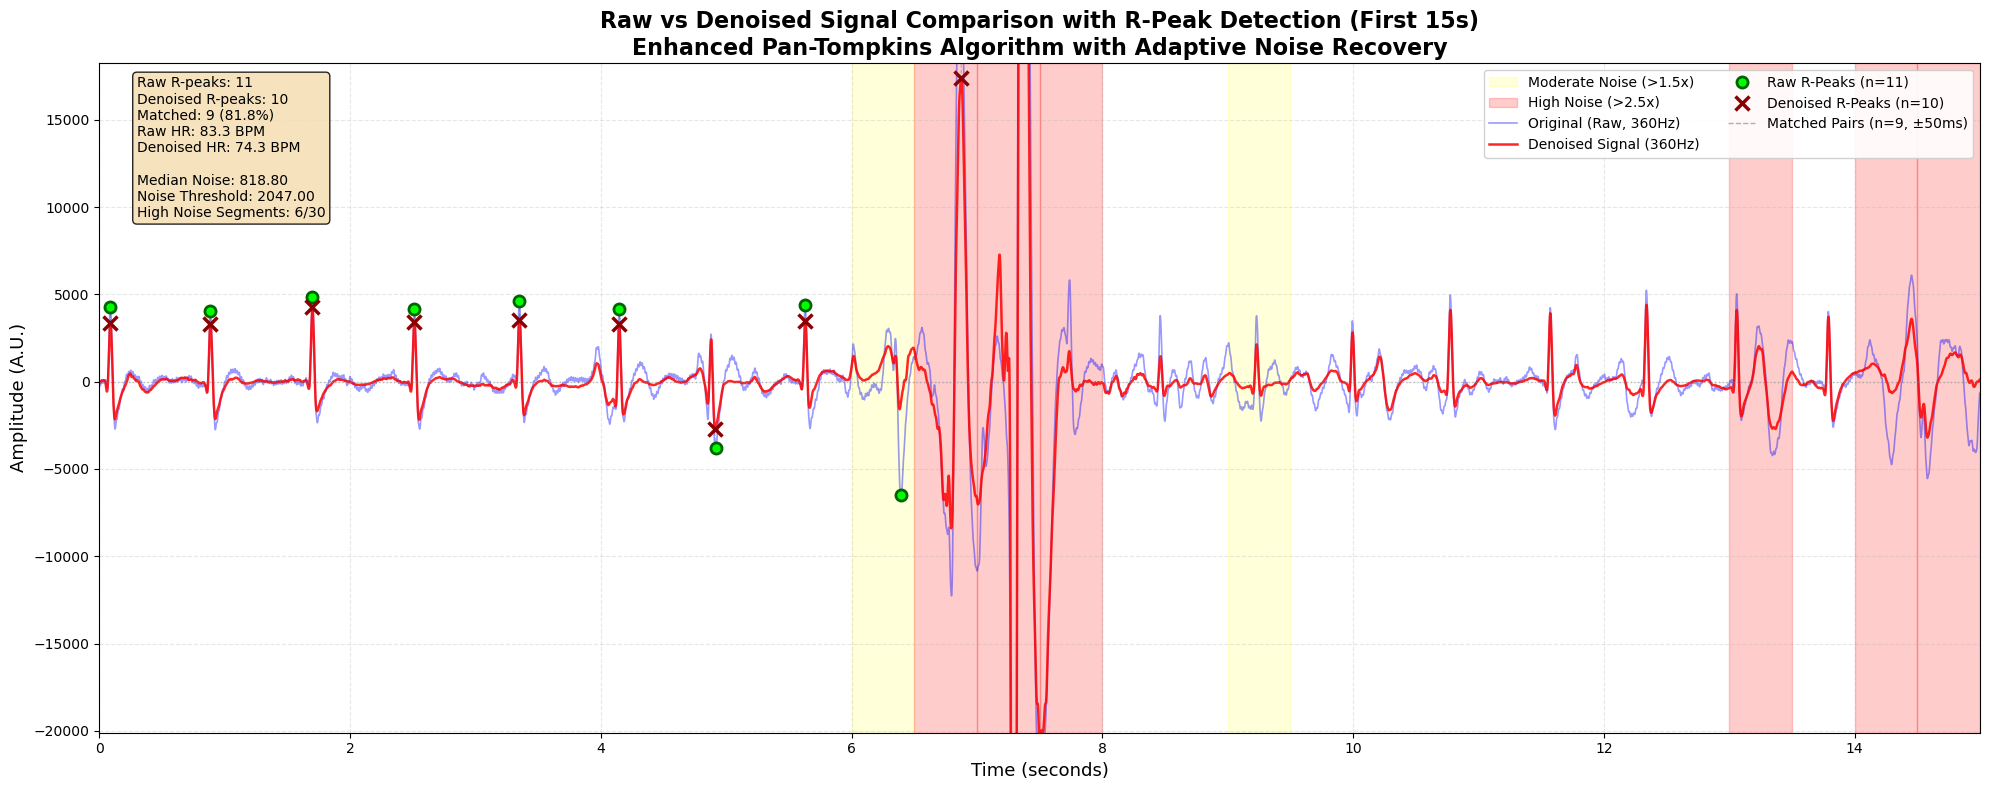


R-PEAK DETECTION COMPARISON (First 15s)
  Raw signal R-peaks detected:        11
  Denoised signal R-peaks detected:   10
  Matched pairs (±50ms):               9 ( 81.8%)
  Difference:                         -1
  Unmatched raw peaks:                 2 (potential false negatives)
  Unmatched denoised peaks:            1 (potential false positives)

  Raw Heart Rate:                     83.3 BPM
  Denoised Heart Rate:                74.3 BPM
  HR Difference:                      -9.0 BPM (-10.8%)

  Raw RR-RMSSD:                      102.0 ms
  Denoised RR-RMSSD:                 327.1 ms
  RMSSD Reduction:                  -225.2 ms (-220.8%)

  Noise Analysis------------------------------------------------------
  Total segments analyzed:            30 (0.5s each)
  Clean segments:                     22
  Moderate noise segments:             2
  High noise segments:                 6
  Median noise level:                 818.80
  Max noise level:                   9726.79
  Noise th

In [179]:
# === 11. Diagnostic Visualization: Raw vs Denoised with R-Peaks ===

def visualize_rpeak_comparison(raw_sig, deno_sig, rpeak_raw, rpeak_deno, fs, seconds_to_show=10):
    """
    원본 및 디노이징된 신호를 오버레이하고 검출된 R-peak을 마커로 표시합니다.
    노이즈 구간도 함께 표시하여 알고리즘의 강건성을 시각적으로 확인합니다.
    """
    total_samples = len(raw_sig)
    samples_to_show = int(fs * seconds_to_show)
    samples_to_show = min(total_samples, samples_to_show)
    
    time_sec = np.linspace(0, (total_samples - 1) / fs, total_samples)[:samples_to_show]
    
    # 시각화할 샘플 범위 내의 R-peak만 필터링
    rpeak_raw_plot = rpeak_raw[(rpeak_raw < samples_to_show)]
    rpeak_deno_plot = rpeak_deno[(rpeak_deno < samples_to_show)]
    
    # 노이즈 레벨 계산 (0.5초 구간별 - 더 세밀하게)
    segment_duration = int(0.5 * fs)  # 0.5초
    num_segments = samples_to_show // segment_duration
    noise_segments = []
    
    for seg_idx in range(num_segments):
        seg_start = seg_idx * segment_duration
        seg_end = min(seg_start + segment_duration, samples_to_show)
        seg_raw = raw_sig[seg_start:seg_end]
        
        # MAD 기반 노이즈 추정
        median_val = np.median(seg_raw)
        mad = np.median(np.abs(seg_raw - median_val))
        noise_level = mad * 1.4826
        
        noise_segments.append({
            'start': seg_start / fs,
            'end': seg_end / fs,
            'noise_level': noise_level
        })
    
    # 노이즈 임계값 (중앙값의 2.5배)
    noise_levels_list = [ns['noise_level'] for ns in noise_segments]
    median_noise = np.median(noise_levels_list)
    noise_threshold = median_noise * 2.5
    
    # y축 범위 계산 (백분위수 기반으로 극단값 제외)
    raw_segment = raw_sig[:samples_to_show]
    deno_segment = deno_sig[:samples_to_show]
    
    # 1st와 99th 백분위수 계산 (노이즈 극단값 제외)
    all_values = np.concatenate([raw_segment, deno_segment])
    y_min, y_max = np.percentile(all_values, [1, 99])
    
    # 15% 마진 추가
    y_margin = (y_max - y_min) * 0.15
    y_limits = [y_min - y_margin, y_max + y_margin]

    plt.figure(figsize=(20, 8))
    
    # 0. 노이즈 구간 배경 표시 (3단계 색상)
    high_noise_shown = False
    moderate_noise_shown = False
    
    for ns in noise_segments:
        if ns['noise_level'] > noise_threshold:
            # 높은 노이즈 (빨간색)
            plt.axvspan(ns['start'], ns['end'], alpha=0.2, color='red', 
                       label='High Noise (>2.5x)' if not high_noise_shown else None)
            high_noise_shown = True
        elif ns['noise_level'] > median_noise * 1.5:
            # 중간 노이즈 (노란색)
            plt.axvspan(ns['start'], ns['end'], alpha=0.15, color='yellow', 
                       label='Moderate Noise (>1.5x)' if not moderate_noise_shown else None)
            moderate_noise_shown = True
    
    # 1. 원본 신호 (옅은 파란색)
    plt.plot(time_sec, raw_sig[:samples_to_show], 'b-', alpha=0.4, 
             label=f'Original (Raw, {fs}Hz)', linewidth=1.2)
    
    # 2. 디노이징 신호 (진한 빨간색)
    plt.plot(time_sec, deno_sig[:samples_to_show], 'r-', alpha=0.85, 
             label=f'Denoised Signal ({fs}Hz)', linewidth=1.8)
    
    # 3. 원본 R-Peak 마커 (녹색 원)
    if len(rpeak_raw_plot) > 0:
        plt.plot(rpeak_raw_plot / fs, raw_sig[rpeak_raw_plot], 'o', 
                 markerfacecolor='lime', markeredgecolor='darkgreen', markersize=8, 
                 markeredgewidth=2, label=f'Raw R-Peaks (n={len(rpeak_raw_plot)})', zorder=5)
    
    # 4. 디노이징 R-Peak 마커 (빨간색 X)
    if len(rpeak_deno_plot) > 0:
        plt.plot(rpeak_deno_plot / fs, deno_sig[rpeak_deno_plot], 'x', 
                 markeredgecolor='darkred', markersize=10, markeredgewidth=2.5, 
                 label=f'Denoised R-Peaks (n={len(rpeak_deno_plot)})', zorder=5)
    
    # 5. R-peak 매칭 연결선 (가까운 피크들)
    matching_threshold_samples = int(0.05 * fs)  # 50ms
    matched_pairs = []
    
    for idx_raw in rpeak_raw_plot:
        if len(rpeak_deno_plot) == 0:
            continue
        distances = np.abs(rpeak_deno_plot - idx_raw)
        closest_idx = np.argmin(distances)
        
        if distances[closest_idx] <= matching_threshold_samples:
            matched_pairs.append((idx_raw, rpeak_deno_plot[closest_idx]))
    
    # 매칭된 피크 연결 (연한 회색 점선)
    for raw_idx, deno_idx in matched_pairs:
        plt.plot([raw_idx / fs, deno_idx / fs], 
                [raw_sig[raw_idx], deno_sig[deno_idx]], 
                'k--', alpha=0.2, linewidth=0.8)
    
    if matched_pairs:
        plt.plot([], [], 'k--', alpha=0.3, linewidth=1.0, 
                label=f'Matched Pairs (n={len(matched_pairs)}, ±50ms)')
    
    # 6. 베이스라인 (0) 표시
    plt.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    
    # 통계 정보 텍스트 박스 (더 상세하게)
    stats_text = f'Raw R-peaks: {len(rpeak_raw_plot)}\n'
    stats_text += f'Denoised R-peaks: {len(rpeak_deno_plot)}\n'
    stats_text += f'Matched: {len(matched_pairs)} ({len(matched_pairs)/max(len(rpeak_raw_plot),1)*100:.1f}%)\n'
    
    if len(rpeak_raw_plot) > 1:
        raw_hr = 60 * fs / np.mean(np.diff(rpeak_raw_plot))
        stats_text += f'Raw HR: {raw_hr:.1f} BPM\n'
    if len(rpeak_deno_plot) > 1:
        deno_hr = 60 * fs / np.mean(np.diff(rpeak_deno_plot))
        stats_text += f'Denoised HR: {deno_hr:.1f} BPM\n'
    
    stats_text += f'\nMedian Noise: {median_noise:.2f}\n'
    stats_text += f'Noise Threshold: {noise_threshold:.2f}\n'
    
    high_noise_count = sum(1 for ns in noise_segments if ns['noise_level'] > noise_threshold)
    stats_text += f'High Noise Segments: {high_noise_count}/{len(noise_segments)}'
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85))
    
    plt.title(f'Raw vs Denoised Signal Comparison with R-Peak Detection (First {seconds_to_show}s)\n' +
              f'Enhanced Pan-Tompkins Algorithm with Adaptive Noise Recovery', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Time (seconds)', fontsize=13)
    plt.ylabel('Amplitude (A.U.)', fontsize=13)
    plt.ylim(y_limits)
    plt.xlim([0, seconds_to_show])
    plt.legend(loc='upper right', fontsize=10, framealpha=0.9, ncol=2)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # 추가: R-peak 매칭 분석 (더 상세하게)
    print(f"\n{'='*70}")
    print(f"R-PEAK DETECTION COMPARISON (First {seconds_to_show}s)")
    print(f"{'='*70}")
    print(f"  Raw signal R-peaks detected:      {len(rpeak_raw_plot):4d}")
    print(f"  Denoised signal R-peaks detected: {len(rpeak_deno_plot):4d}")
    print(f"  Matched pairs (±50ms):            {len(matched_pairs):4d} ({len(matched_pairs)/max(len(rpeak_raw_plot),1)*100:5.1f}%)")
    print(f"  Difference:                       {len(rpeak_deno_plot) - len(rpeak_raw_plot):+4d}")
    
    # 미매칭 분석
    unmatched_raw = len(rpeak_raw_plot) - len(matched_pairs)
    unmatched_deno = len(rpeak_deno_plot) - len(matched_pairs)
    print(f"  Unmatched raw peaks:              {unmatched_raw:4d} (potential false negatives)")
    print(f"  Unmatched denoised peaks:         {unmatched_deno:4d} (potential false positives)")
    
    if len(rpeak_raw_plot) > 1 and len(rpeak_deno_plot) > 1:
        raw_hr = 60 * fs / np.mean(np.diff(rpeak_raw_plot))
        deno_hr = 60 * fs / np.mean(np.diff(rpeak_deno_plot))
        print(f"\n  Raw Heart Rate:                   {raw_hr:6.1f} BPM")
        print(f"  Denoised Heart Rate:              {deno_hr:6.1f} BPM")
        print(f"  HR Difference:                    {deno_hr - raw_hr:+6.1f} BPM ({(deno_hr - raw_hr)/raw_hr*100:+5.1f}%)")
        
        # RR 간격 변동성 (RMSSD)
        raw_rr_intervals = np.diff(rpeak_raw_plot)
        deno_rr_intervals = np.diff(rpeak_deno_plot)
        
        raw_rmssd = np.sqrt(np.mean(np.diff(raw_rr_intervals)**2)) / fs * 1000
        deno_rmssd = np.sqrt(np.mean(np.diff(deno_rr_intervals)**2)) / fs * 1000
        
        print(f"\n  Raw RR-RMSSD:                     {raw_rmssd:6.1f} ms")
        print(f"  Denoised RR-RMSSD:                {deno_rmssd:6.1f} ms")
        print(f"  RMSSD Reduction:                  {raw_rmssd - deno_rmssd:+6.1f} ms ({(raw_rmssd - deno_rmssd)/raw_rmssd*100:+5.1f}%)")
    
    # 노이즈 구간 통계
    high_noise_count = sum(1 for ns in noise_segments if ns['noise_level'] > noise_threshold)
    moderate_noise_count = sum(1 for ns in noise_segments if median_noise * 1.5 < ns['noise_level'] <= noise_threshold)
    
    print(f"\n{'  Noise Analysis':-<70}")
    print(f"  Total segments analyzed:          {len(noise_segments):4d} (0.5s each)")
    print(f"  Clean segments:                   {len(noise_segments) - high_noise_count - moderate_noise_count:4d}")
    print(f"  Moderate noise segments:          {moderate_noise_count:4d}")
    print(f"  High noise segments:              {high_noise_count:4d}")
    print(f"  Median noise level:               {median_noise:8.2f}")
    print(f"  Max noise level:                  {max(noise_levels_list):8.2f}")
    print(f"  Noise threshold (2.5x median):    {noise_threshold:8.2f}")
    print(f"{'='*70}\n")

# 함수 호출 (코드의 가장 마지막 부분에 추가)
visualize_rpeak_comparison(lead2_360, denoised_360, rpeak_raw, rpeak_deno, fs_tgt, seconds_to_show=15)

In [180]:
# === 11.5. Post-Denoising Smoothing (Jitter Removal) ===
# Cell 11 (Signal Metrics) 실행 후, Cell 12 (R-Peak Detection) 이전에 삽입

from scipy.signal import butter, filtfilt # 필요시 임포트 추가

# LPF 파라미터 정의
nyq_tgt = 0.5 * fs_tgt  # Nyquist 주파수 (180 Hz)
cutoff_freq = 50.0      # 50 Hz 저역 통과 필터 (LPF) 적용
normalized_cutoff = cutoff_freq / nyq_tgt
order = 3               # 3차 Butterworth 필터 (ECG 파형 보존에 적합)

# Butterworth 필터 계수 계산
b_lpf, a_lpf = butter(order, normalized_cutoff, btype='low', analog=False)

# Denoised 신호에 LPF 적용 (filtfilt로 위상 지연 방지)
# 기존 denoised_360 변수를 덮어씁니다.
denoised_360 = filtfilt(b_lpf, a_lpf, denoised_360)

print(f"✓ Denoised signal smoothed with {cutoff_freq} Hz LPF (Order: {order})")
print(f"  새로운 denoised_360이 R-peak 검출(Cell 12)에 사용됩니다.")

✓ Denoised signal smoothed with 50.0 Hz LPF (Order: 3)
  새로운 denoised_360이 R-peak 검출(Cell 12)에 사용됩니다.


In [181]:
# === 12. Save Denoised Signals ===

# Save as .npy files
np.save(os.path.join(output_dir, "raw_360Hz.npy"), lead2_360)
np.save(os.path.join(output_dir, "denoised_360Hz.npy"), denoised_360)
np.save(os.path.join(output_dir, "denoised_267Hz.npy"), denoised_267)

# Save R-peak indices
np.save(os.path.join(output_dir, "rpeak_raw_indices.npy"), rpeak_raw)
np.save(os.path.join(output_dir, "rpeak_deno_indices.npy"), rpeak_deno)

print(f"✓ Signals saved to {output_dir}/:")
print(f"  - raw_360Hz.npy")
print(f"  - denoised_360Hz.npy")
print(f"  - denoised_267Hz.npy")
print(f"  - rpeak_raw_indices.npy")
print(f"  - rpeak_deno_indices.npy")
print(f"  - rpeak_metrics.json")

✓ Signals saved to ajou_outputs/:
  - raw_360Hz.npy
  - denoised_360Hz.npy
  - denoised_267Hz.npy
  - rpeak_raw_indices.npy
  - rpeak_deno_indices.npy
  - rpeak_metrics.json


In [182]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import IntSlider, Output, interact, VBox, Layout, HBox, Label
from IPython.display import display

# --- Assuming these variables are defined in the preceding cells ---
# Replace with actual dummy data if you're testing this without the full notebook context
try:
    # Check if essential variables exist (standard practice in a full notebook)
    len(lead2_360), len(denoised_360), fs_tgt, len(rpeak_raw), len(rpeak_deno)
except NameError:
    # Define dummy data for demonstration if variables are missing
    print("Warning: Using dummy data for demonstration.")
    fs_tgt = 360  # Target sampling frequency
    total_duration = 300  # 300 seconds
    total_samples = int(total_duration * fs_tgt)
    t = np.arange(total_samples) / fs_tgt
    
    # Simple sine wave approximation for ECG
    freq = 1.0  # ~60 BPM
    lead2_360 = np.sin(2 * np.pi * freq * t) + 0.5 * np.random.randn(total_samples) * 0.1 # Raw ECG (with noise)
    denoised_360 = np.sin(2 * np.pi * freq * t) # Denoised ECG
    
    # Dummy R-peaks (simple periodic)
    rpeak_indices = np.arange(0, total_samples, int(fs_tgt / freq))
    rpeak_raw = rpeak_indices
    rpeak_deno = rpeak_indices
    
    # Re-calculate total_samples after creating dummy data
    total_samples = len(lead2_360)


import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import IntSlider, Output, interact, VBox, Layout, HBox, Label
from IPython.display import display

# --- 13. Interactive Visualization: R-Peak Detection ---

def plot_rpeak_interactive(start_idx=0):
    """
    Interactive visualization of R-peaks on Raw and Denoised ECG signals.
    
    Args:
        start_idx: Starting index in samples (for scrolling)
    """
    # NOTE: This function assumes 'fs_tgt', 'lead2_360', 'denoised_360', 
    # 'rpeak_raw', and 'rpeak_deno' are defined by preceding cells.
    
    window_duration = 10.0  # Display 10 seconds at a time
    window_samples = int(window_duration * fs_tgt)
    
    # Boundary check
    total_samples = len(lead2_360)
    start_idx = min(start_idx, total_samples - window_samples)
    start_idx = max(0, start_idx)
    end_idx = min(start_idx + window_samples, total_samples)
    
    # Time axis
    t_start = start_idx / fs_tgt
    t_end = end_idx / fs_tgt
    t_vis = np.arange(start_idx, end_idx) / fs_tgt
    
    # Get signals
    raw_segment = lead2_360[start_idx:end_idx]
    deno_segment = denoised_360[start_idx:end_idx]
    
    # Calculate y-axis limits using percentiles to handle outliers/noise
    # This prevents extreme noise values from dominating the plot scale
    raw_p1, raw_p99 = np.percentile(raw_segment, [1, 99])
    deno_p1, deno_p99 = np.percentile(deno_segment, [1, 99])
    
    # Add some margin (10%) for better visualization
    raw_margin = (raw_p99 - raw_p1) * 0.1
    deno_margin = (deno_p99 - deno_p1) * 0.1
    
    raw_ylim = [raw_p1 - raw_margin, raw_p99 + raw_margin]
    deno_ylim = [deno_p1 - deno_margin, deno_p99 + deno_margin]
    
    # Filter R-peaks in visualization window
    rpeak_raw_vis = rpeak_raw[(rpeak_raw >= start_idx) & (rpeak_raw < end_idx)]
    rpeak_deno_vis = rpeak_deno[(rpeak_deno >= start_idx) & (rpeak_deno < end_idx)]
    
    # Convert indices to time
    rpeak_raw_time = rpeak_raw_vis / fs_tgt
    rpeak_deno_time = rpeak_deno_vis / fs_tgt
    
    # Get amplitude values at R-peaks (using integer arrays for indexing)
    raw_rpeak_amp = lead2_360[rpeak_raw_vis]
    deno_rpeak_amp = denoised_360[rpeak_deno_vis]
    
    # Create interactive Plotly figure
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.1,
        subplot_titles=[
            f"Raw ECG Signal with R-peaks (Window: {t_start:.2f}~{t_end:.2f}s, n={len(rpeak_raw_vis)})",
            f"Denoised ECG Signal with R-peaks (Window: {t_start:.2f}~{t_end:.2f}s, n={len(rpeak_deno_vis)})",
        ],
    )
    
    # Plot 1: Raw ECG with R-peaks
    fig.add_trace(
        go.Scatter(
            x=t_vis,
            y=raw_segment,
            mode='lines',
            name='Raw ECG',
            line=dict(color='#1f77b4', width=1.5),
            hovertemplate='Time: %{x:.3f}s<br>Amplitude: %{y:.4f} mV<extra></extra>',
        ),
        row=1, col=1
    )
    
    # R-peaks on raw signal (red circles)
    if len(rpeak_raw_vis) > 0:
        fig.add_trace(
            go.Scatter(
                x=rpeak_raw_time,
                y=raw_rpeak_amp,
                mode='markers',
                name='R-peaks (Raw)',
                marker=dict(
                    size=10,
                    color='red',
                    symbol='circle',
                    line=dict(color='darkred', width=2)
                ),
                hovertemplate='R-peak Time: %{x:.3f}s<br>Amplitude: %{y:.4f} mV<extra></extra>',
            ),
            row=1, col=1
        )
    
    # Plot 2: Denoised ECG with R-peaks
    fig.add_trace(
        go.Scatter(
            x=t_vis,
            y=deno_segment,
            mode='lines',
            name='Denoised ECG',
            line=dict(color='#2ca02c', width=1.5),
            hovertemplate='Time: %{x:.3f}s<br>Amplitude: %{y:.4f} mV<extra></extra>',
        ),
        row=2, col=1
    )
    
    # R-peaks on denoised signal (red circles)
    if len(rpeak_deno_vis) > 0:
        fig.add_trace(
            go.Scatter(
                x=rpeak_deno_time,
                y=deno_rpeak_amp,
                mode='markers',
                name='R-peaks (Denoised)',
                marker=dict(
                    size=10,
                    color='red',
                    symbol='circle',
                    line=dict(color='darkred', width=2)
                ),
                hovertemplate='R-peak Time: %{x:.3f}s<br>Amplitude: %{y:.4f} mV<extra></extra>',
            ),
            row=2, col=1
        )
    
    # Update layout
    fig.update_yaxes(title_text='Amplitude (mV)', range=raw_ylim, row=1, col=1)
    fig.update_yaxes(title_text='Amplitude (mV)', range=deno_ylim, row=2, col=1)
    fig.update_xaxes(title_text='Time (s)', row=2, col=1)
    
    fig.update_layout(
        height=700,
        width=1400,
        title_text='Interactive R-Peak Detection Comparison (Pan-Tompkins Algorithm)',
        template='plotly_white',
        hovermode='x unified',
        legend=dict(orientation='h', yanchor='top', y=1.0, xanchor='left', x=0.05),
        margin=dict(l=60, r=40, t=100, b=60),
    )
    
    return fig

# --- Interactive Setup ---
# Assume total_samples, fs_tgt, etc., are defined by preceding cells.

total_samples = len(lead2_360)
window_duration = 10.0
window_samples = int(window_duration * fs_tgt)  # 10-second window
max_start_idx = max(0, total_samples - window_samples)

# Create the slider
slider = IntSlider(
    value=0,
    min=0,
    max=max_start_idx,
    step=int(fs_tgt),  # Step by 1 second worth of samples
    description='Start Sample Index:',
    layout=Layout(width='90%'),
)

# Create a Label to show current time
current_time_label = Label(f"Current Start Time: 0.00s")

def update_label(change):
    start_time = change.new / fs_tgt
    current_time_label.value = f"Current Start Time: {start_time:.2f}s"

slider.observe(update_label, names='value')

# The core interactive command
@interact(start_idx=slider)
def update_plot_interact(start_idx):
    """Function called by interact to update the plot."""
    return plot_rpeak_interactive(start_idx)

# Display helper information
print(f"\n✓ Interactive R-Peak Visualization Ready")
print(f"  Total signal duration: {total_samples / fs_tgt:.2f} seconds")
print(f"  Window size: 10 seconds ({window_samples} samples)")
print(f"  Use the slider above to scroll through the signal")
display(HBox([current_time_label], layout=Layout(justify_content='center')))

interactive(children=(IntSlider(value=0, description='Start Sample Index:', layout=Layout(width='90%'), max=20…


✓ Interactive R-Peak Visualization Ready
  Total signal duration: 591.24 seconds
  Window size: 10 seconds (3600 samples)
  Use the slider above to scroll through the signal
